## Import libraries

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))
os.chdir(project_root)



In [7]:
from IPython.display import Image

from fmu2ml.analysis.multivariate_effect_analysis.analyzers import (
    PartialCorrelationAnalyzer,
    MultipleRegressionAnalyzer,
    LaggedEffectAnalyzer,
    AutocorrelationAnalyzer
)
from fmu2ml.analysis.multivariate_effect_analysis.visualizers import *
from fmu2ml.analysis.input_output_relations.analyzers import DataGenerator
from raps.config import ConfigManager

sns.set_style("whitegrid")
%matplotlib inline

In [ ]:
SYSTEM_NAME = 'marconi100'
config = ConfigManager(system_name=SYSTEM_NAME).get_config()
num_cdus = config['NUM_CDUS']

In [4]:
# Configuration
N_SAMPLES = 1000
MAX_LAG = 30
OUTPUT_DIR = f'../results/{SYSTEM_NAME}/data_analysis/multivariate_effect'
DATA_DIR = f'../results/{SYSTEM_NAME}/data_analysis/direct_effect_analysis'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Input ranges
INPUT_RANGES = {
    'Q_flow': (12.0, 40.0),    # kW
    'T_Air': (288.15, 308.15),   # K
    'T_ext': (283.15, 313.15)    # K
}

# Parallel settings
N_WORKERS = 48
THREADS_PER_WORKER = 1
MEMORY_LIMIT = '64GB'
KEY_OUTPUTS = ['T_sec_r_C', 'W_flow_CDUP_kW', 'V_flow_sec_GPM','p_sec_r_psig']

print(f"System: {SYSTEM_NAME}")
print(f"Samples: {N_SAMPLES}")
print(f"Workers: {N_WORKERS}")
print(f"Max lag: {MAX_LAG}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Number of CDUs: {num_cdus}")
print(f"Configuration loaded for {SYSTEM_NAME}")



System: marconi100
Samples: 1000
Workers: 48
Max lag: 30
Output dir: ../results/marconi100/data_analysis/multivariate_effect
Number of CDUs: 49
Configuration loaded for marconi100


In [5]:
data_file = os.path.join(DATA_DIR, 'sensitivity_data.parquet')


In [6]:
# Generate or Load Data
data_generator = DataGenerator(
    n_workers=N_WORKERS,
    **config
)
data = None
if os.path.exists(data_file):
    print("Importing the previously generated data")
    data = pd.read_parquet(data_file)
else:
    print("Generating simulation data...")
    data = data_generator.generate_sensitivity_data(
        total_timesteps=TOTAL_TIMESTEPS,
        samples_per_hour=SAMPLES_PER_HOUR,
        input_ranges=INPUT_RANGES
    )
    # Save data
    data.to_parquet(data_file)
    print(f"Data saved to: {data_file}")
    
print(f"Data shape: {data.shape}")
print(f"\nColumns: {list(data.columns[:10])}...")

2026-02-05 06:14:25 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - DataGenerator initialized for system: marconi100
2026-02-05 06:14:25 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - Number of CDUs: 49


Importing the previously generated data
Data shape: (7200, 1230)

Columns: ['simulator[1].datacenter[1].summary.m_flow_prim', 'simulator[1].datacenter[1].summary.V_flow_prim_GPM', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_prim', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_prim_GPM', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_sec', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_sec_GPM', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP_kW', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C']...


## 1. Partial Correlation Analysis

In [33]:

# Partial Correlation Analysis - Setup
partial_analyzer = PartialCorrelationAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    significance_threshold=0.05,
    edge_threshold=0.1,
    method='pearson'
)

prepared_data = partial_analyzer.prepare_data(data)


2026-01-29 18:03:57 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - PartialCorrelationAnalyzer initialized for system: marconi100
2026-01-29 18:03:57 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Method: pearson, Significance threshold: 0.05
2026-01-29 18:03:57 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Preparing data for partial correlation analysis...
2026-01-29 18:03:57 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Prepared data: 3 inputs, 11 outputs, 1 datacenter outputs


In [34]:

# Partial Correlation Analysis - Compute
print("Computing partial correlations...")
partial_df = partial_analyzer.analyze_partial_correlations(prepared_data)

print(f"\nTotal relationships analyzed: {len(partial_df)}")
print(f"Direct effects identified: {partial_df['is_direct_effect'].sum()}")


2026-01-29 18:04:03 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Computing partial correlations...
2026-01-29 18:04:03 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Initializing Dask cluster for partial correlation analysis...
2026-01-29 18:04:03 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-01-29 18:04:03 - distributed.scheduler - INFO - State start
2026-01-29 18:04:03 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-iz_jj7us', purging
2026-01-29 18:04:03 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-9tguscl3', purging
2026-01-29 18:04:03 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-wvlje2hr', purging
2026-0

Computing partial correlations...


2026-01-29 18:04:03 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:46009'
2026-01-29 18:04:03 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34159'
2026-01-29 18:04:03 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40069'
2026-01-29 18:04:03 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:45521'
2026-01-29 18:04:03 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34809'
2026-01-29 18:04:03 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34667'
2026-01-29 18:04:03 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:44853'
2026-01-29 18:04:03 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:42075'
2026-01-29 18:04:03 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40541'
2026-01-29 18:04:03 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:33153'
2026-01-29 18:04:03 - distribu


Total relationships analyzed: 36
Direct effects identified: 18


2026-01-29 18:07:21 - distributed.scheduler - INFO - Remove client Client-ced9b23c-fd66-11f0-80ba-0a580a221eb4
2026-01-29 18:07:21 - distributed.core - INFO - Received 'close-stream' from tcp://127.0.0.1:54046; closing.
2026-01-29 18:07:21 - distributed.scheduler - INFO - Remove client Client-ced9b23c-fd66-11f0-80ba-0a580a221eb4
2026-01-29 18:07:22 - distributed.scheduler - INFO - Close client connection: Client-ced9b23c-fd66-11f0-80ba-0a580a221eb4
2026-01-29 18:17:27 - distributed.core - INFO - Event loop was unresponsive in Nanny for 4.41s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-01-29 18:17:27 - distributed.core - INFO - Event loop was unresponsive in Nanny for 4.41s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-01-29 18:17:27 - distributed.core - INFO - Event loop was unresponsive in Nanny for 

In [35]:

# Display top direct effects
direct_effects = partial_df[partial_df['is_direct_effect']].copy()
direct_effects['abs_partial'] = direct_effects['partial_corr'].abs()
top_direct = direct_effects.nlargest(10, 'abs_partial')

print("\nTop 10 Direct Effects:")
print(top_direct[['input', 'output', 'pearson_corr', 'partial_corr', ]])



Top 10 Direct Effects:
     input          output  pearson_corr  partial_corr
11  Q_flow             pue     -0.995078     -0.995074
31   T_ext   p_prim_s_psig      0.283582      0.311871
27   T_ext      T_prim_s_C      0.284859      0.311715
3   Q_flow      T_prim_s_C     -0.146705     -0.191424
7   Q_flow   p_prim_s_psig     -0.125300     -0.171436
19   T_Air   p_prim_s_psig     -0.130584     -0.155395
32   T_ext   p_prim_r_psig      0.138392      0.144855
14   T_Air  W_flow_CDUP_kW     -0.126461     -0.132226
17   T_Air       T_sec_s_C     -0.125923     -0.131667
18   T_Air       T_sec_r_C     -0.125905     -0.131586


In [36]:

# Partial Correlation - Visualizations
comparison_data = partial_analyzer.compute_correlation_comparison(prepared_data)
network_data = partial_analyzer.build_network_data(comparison_data['full_results'])

viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'partial_correlation')
os.makedirs(viz_dir, exist_ok=True)

create_correlation_comparison_chart(partial_df, viz_dir)
create_correlation_heatmaps(comparison_data, viz_dir)
create_network_diagram(network_data, viz_dir, layout='spring')
create_confounding_analysis_plot(partial_df, viz_dir)




2026-01-29 18:04:14 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Computing correlation comparison matrices...
2026-01-29 18:04:14 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Computing partial correlations...
2026-01-29 18:04:14 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Executing 36 partial correlation analyses...
2026-01-29 18:04:21 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Computed 36 partial correlations
2026-01-29 18:04:21 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Building network diagram data...
2026-01-29 18:04:21 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Network: 15 nodes, 18 significant edges
2026-01-29 18:04:21 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.p

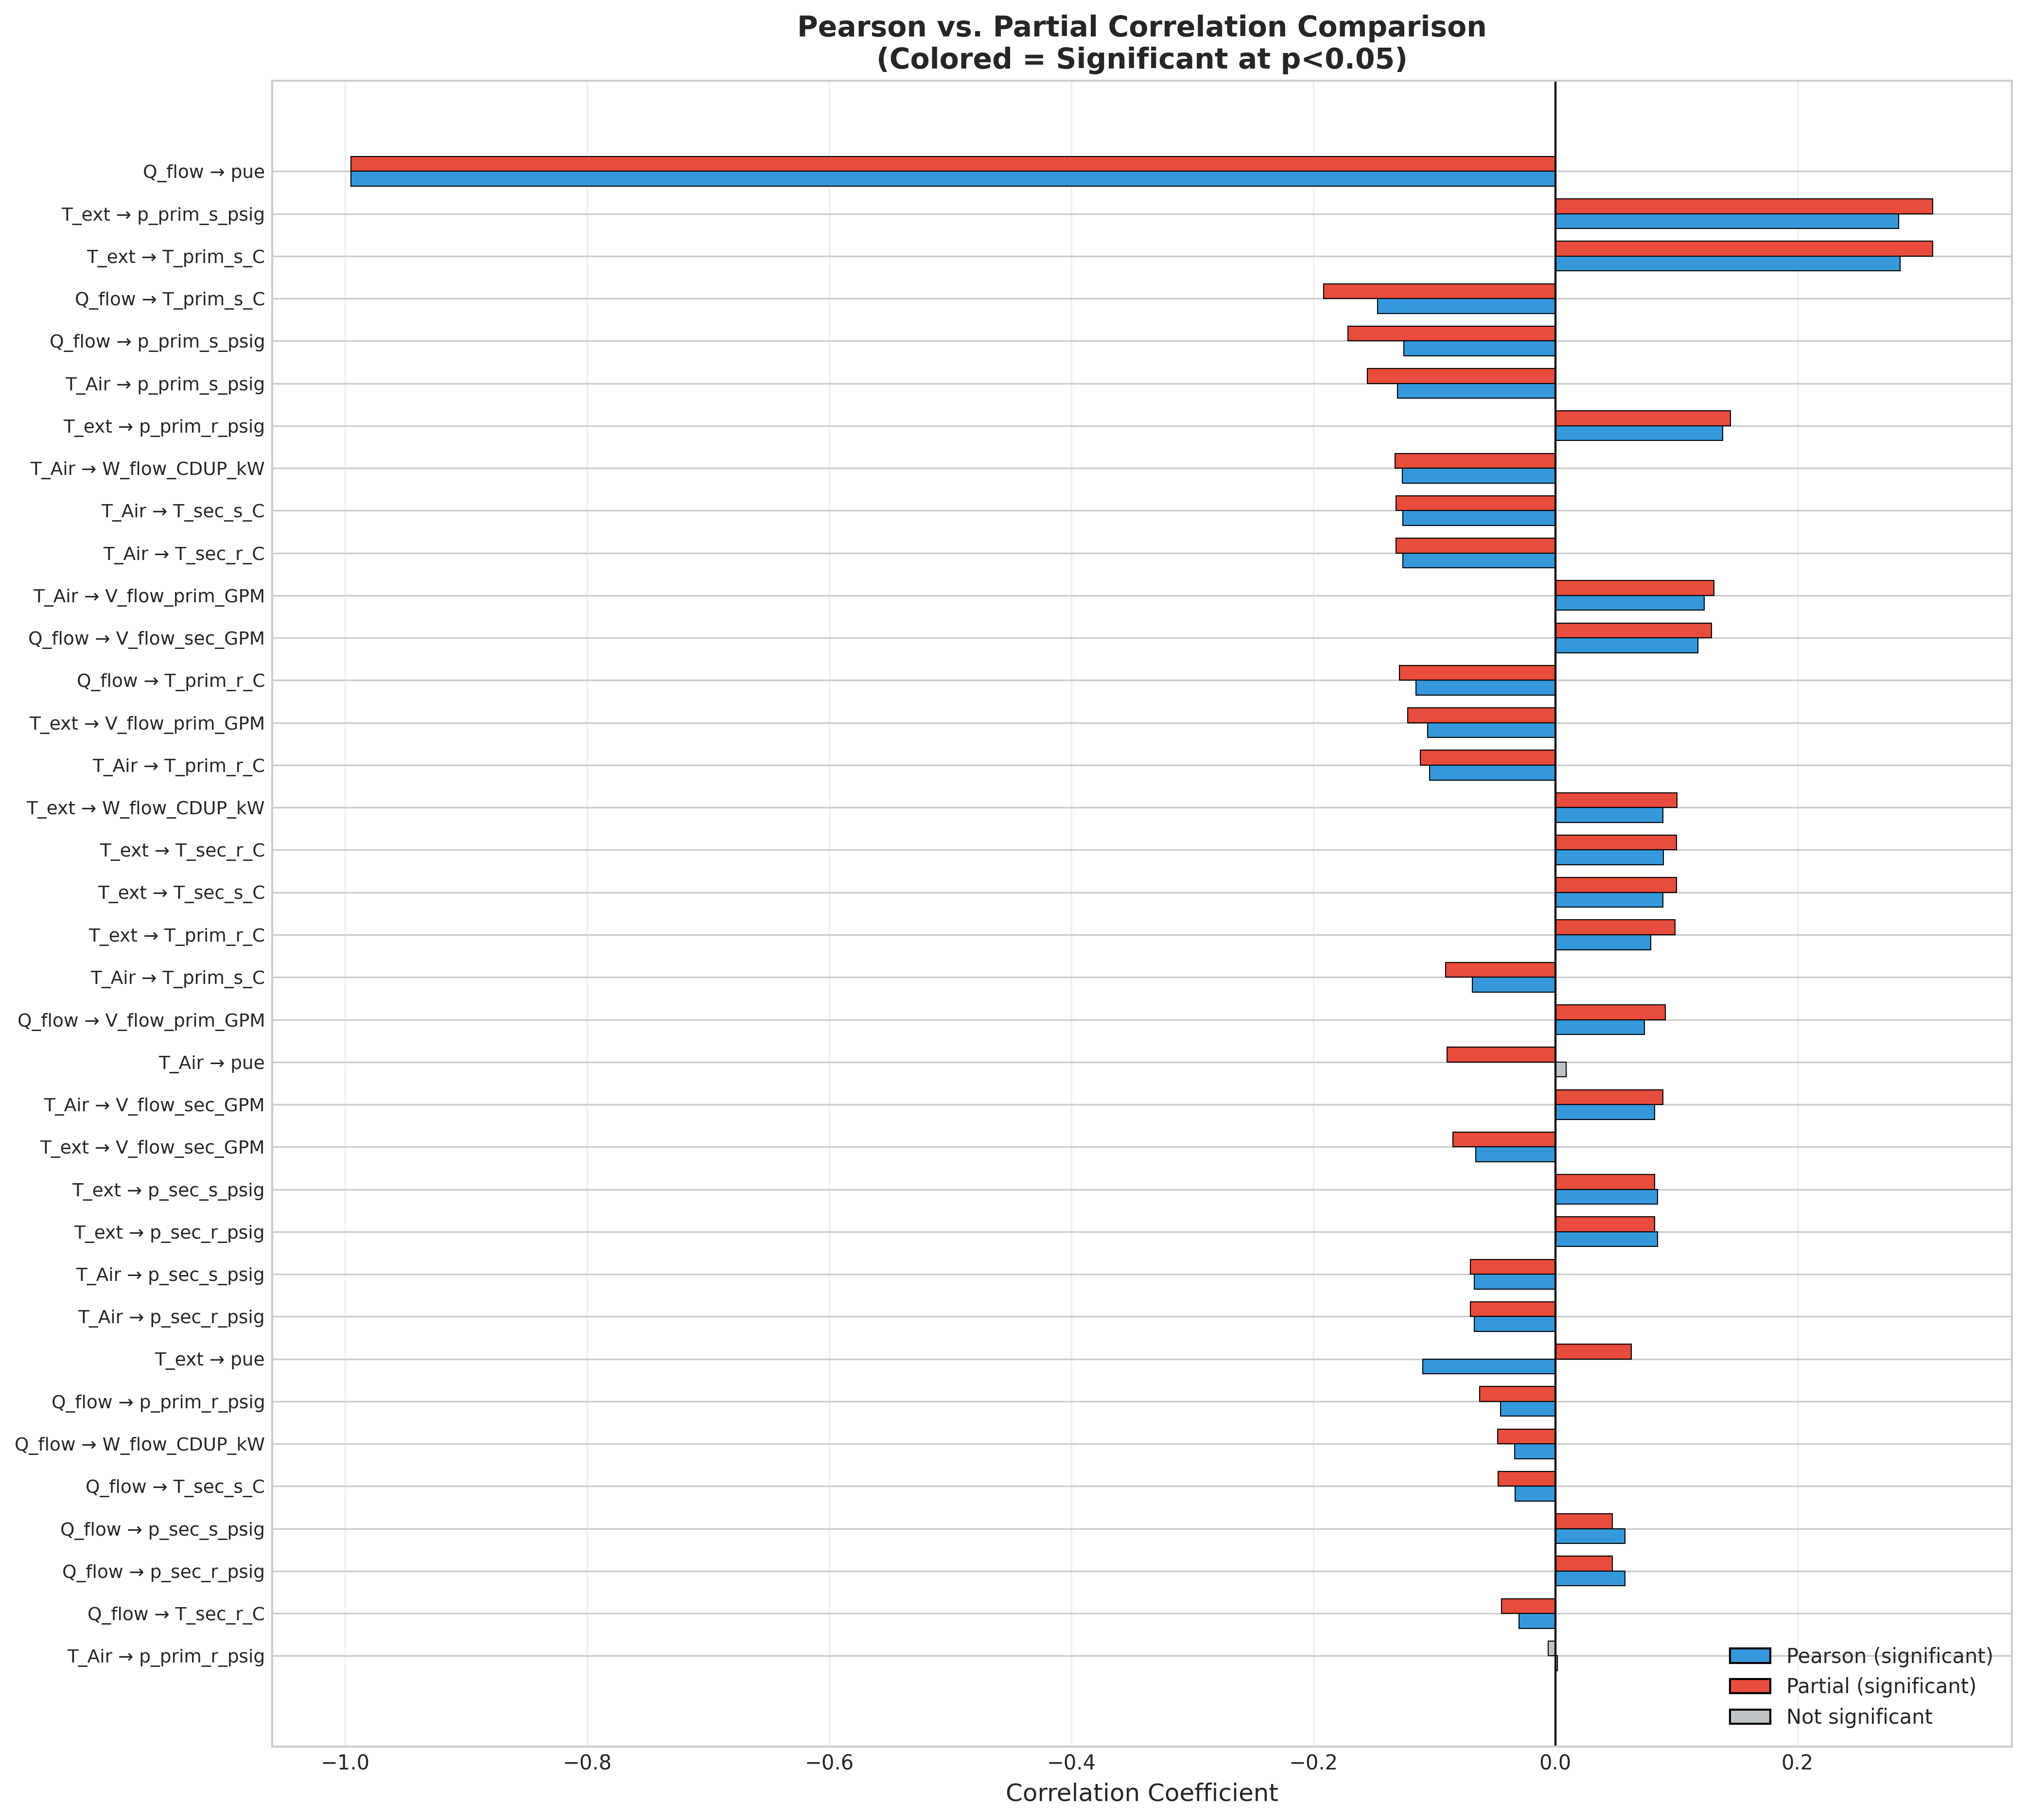

In [12]:

Image(filename=os.path.join(viz_dir, 'correlation_comparison.png'))


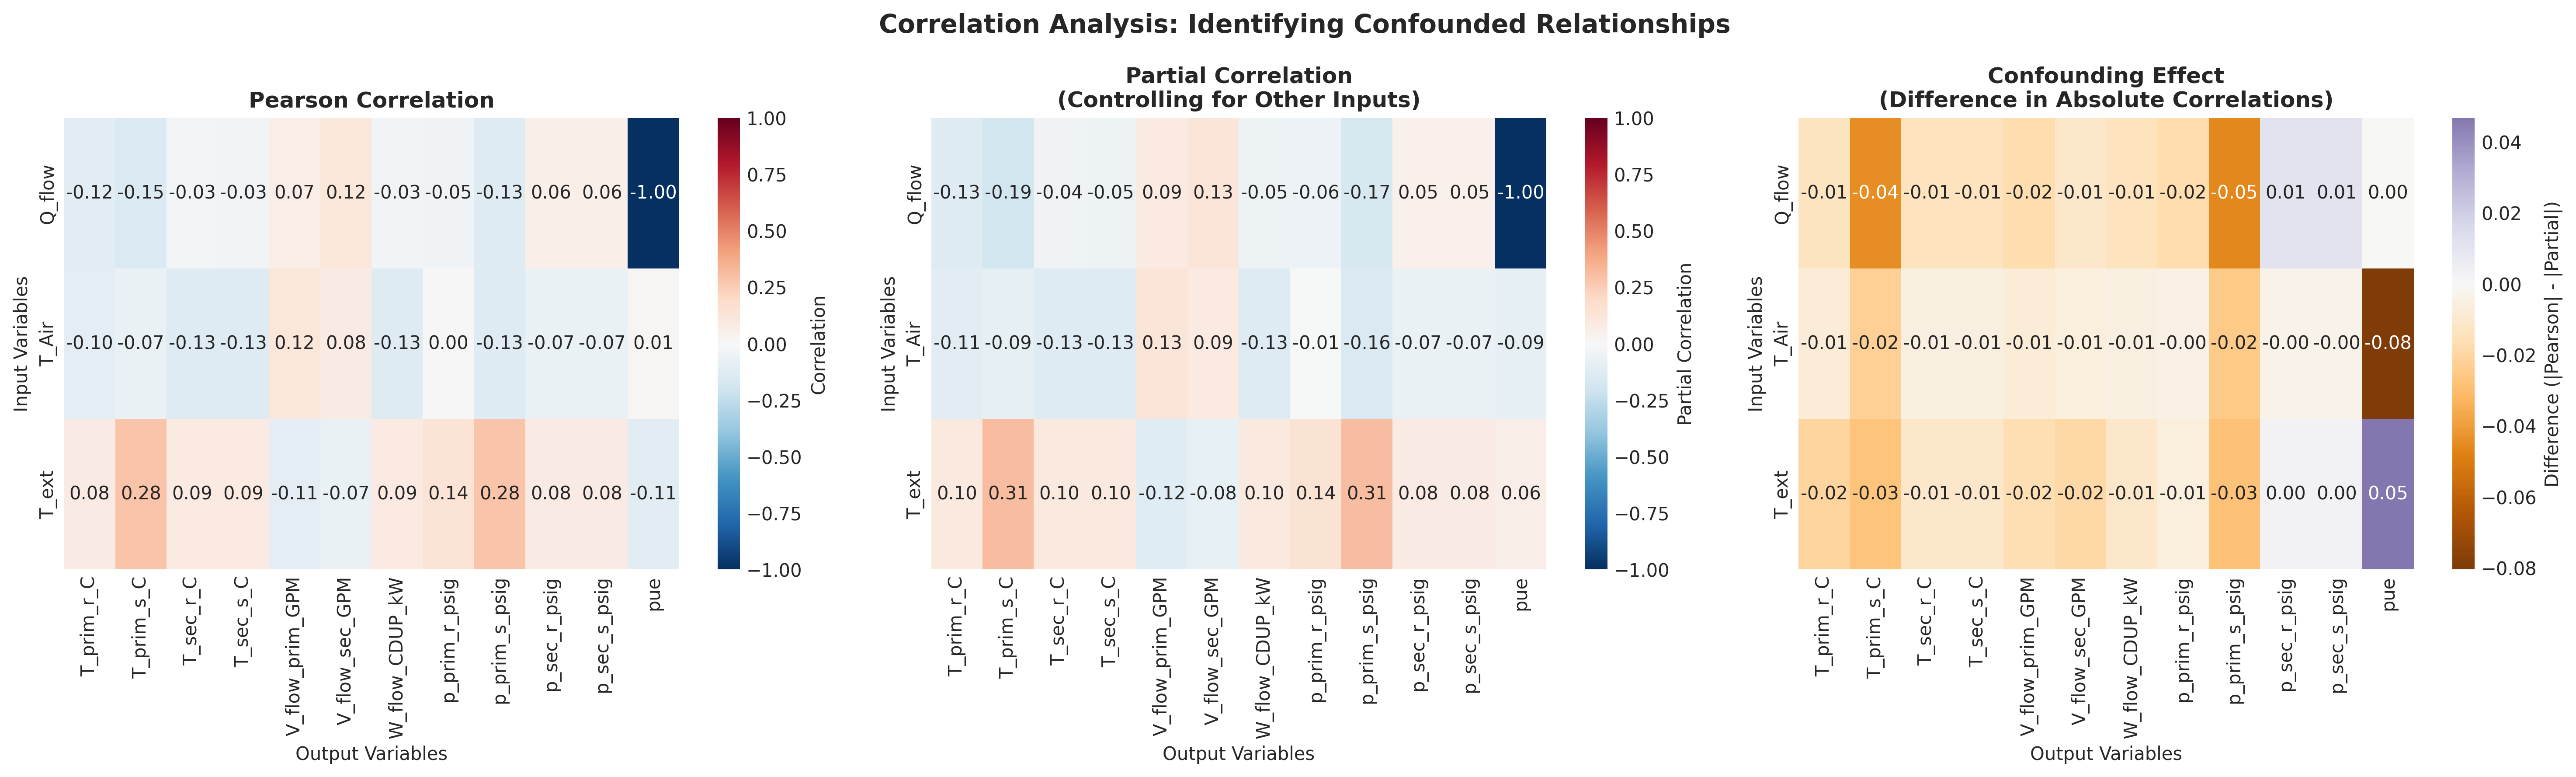

In [10]:
Image(filename=os.path.join(viz_dir, 'correlation_heatmaps.png'))


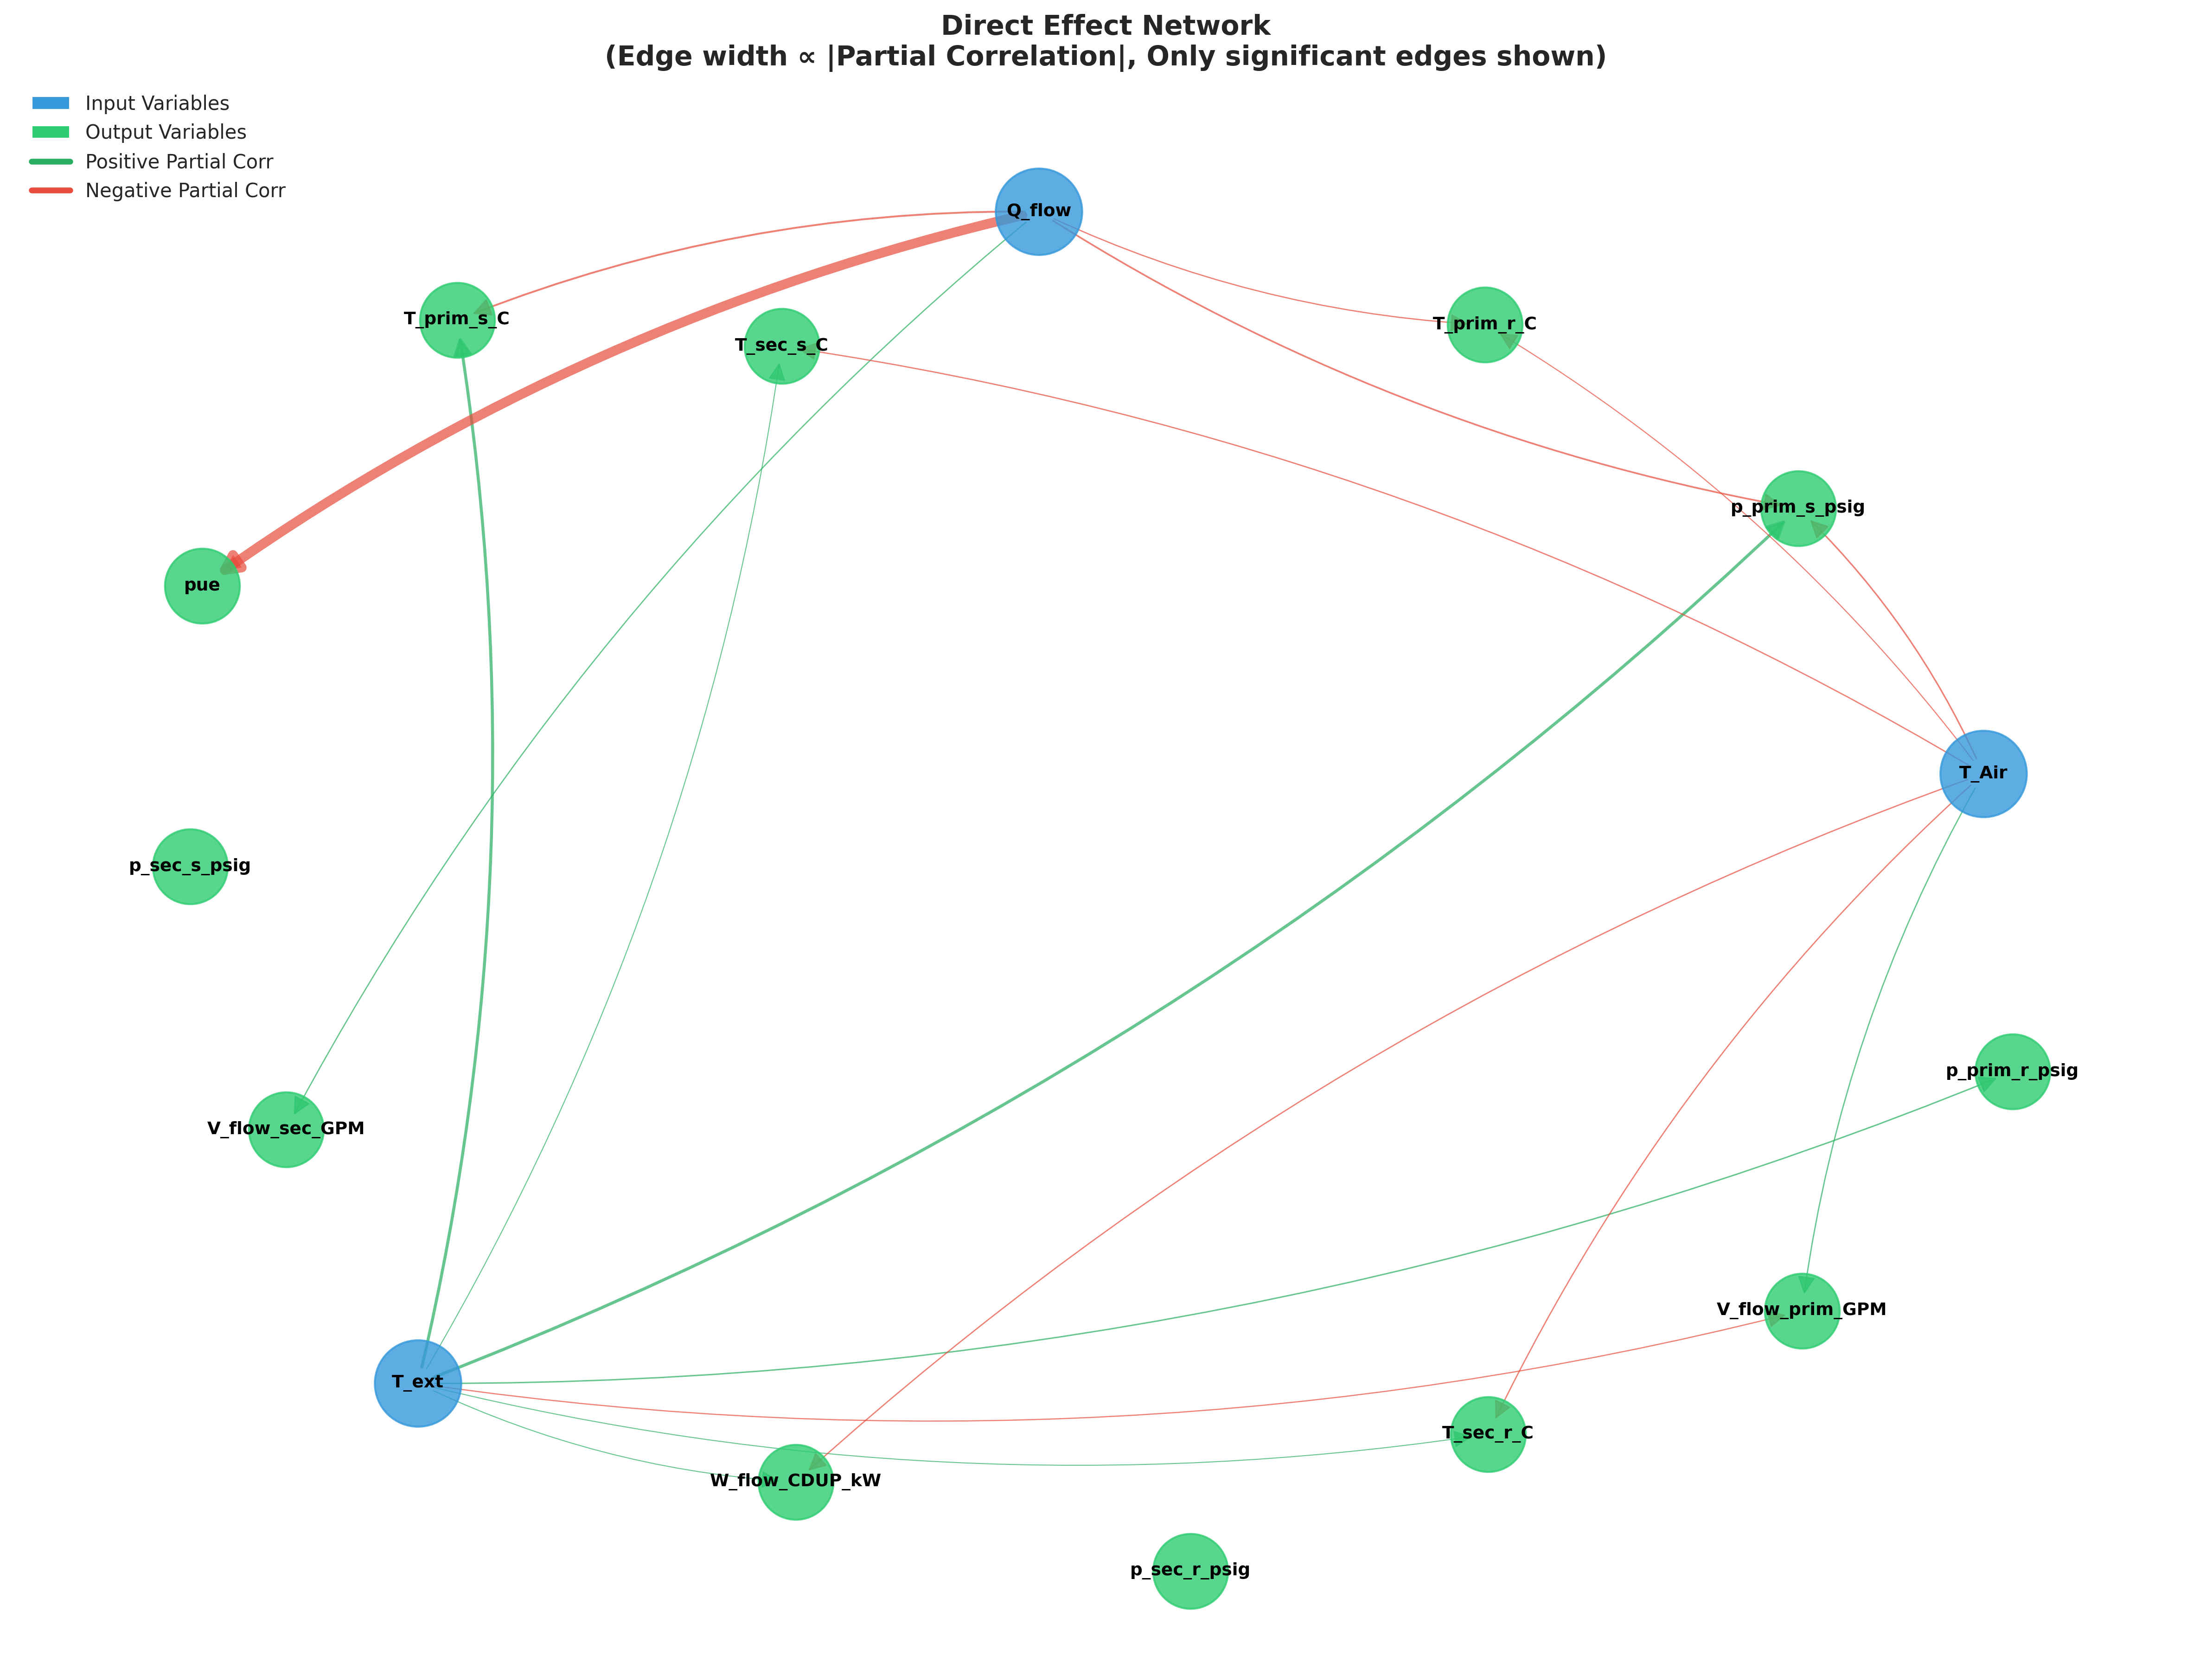

In [13]:
Image(filename=os.path.join(viz_dir, 'direct_effect_network.png'))


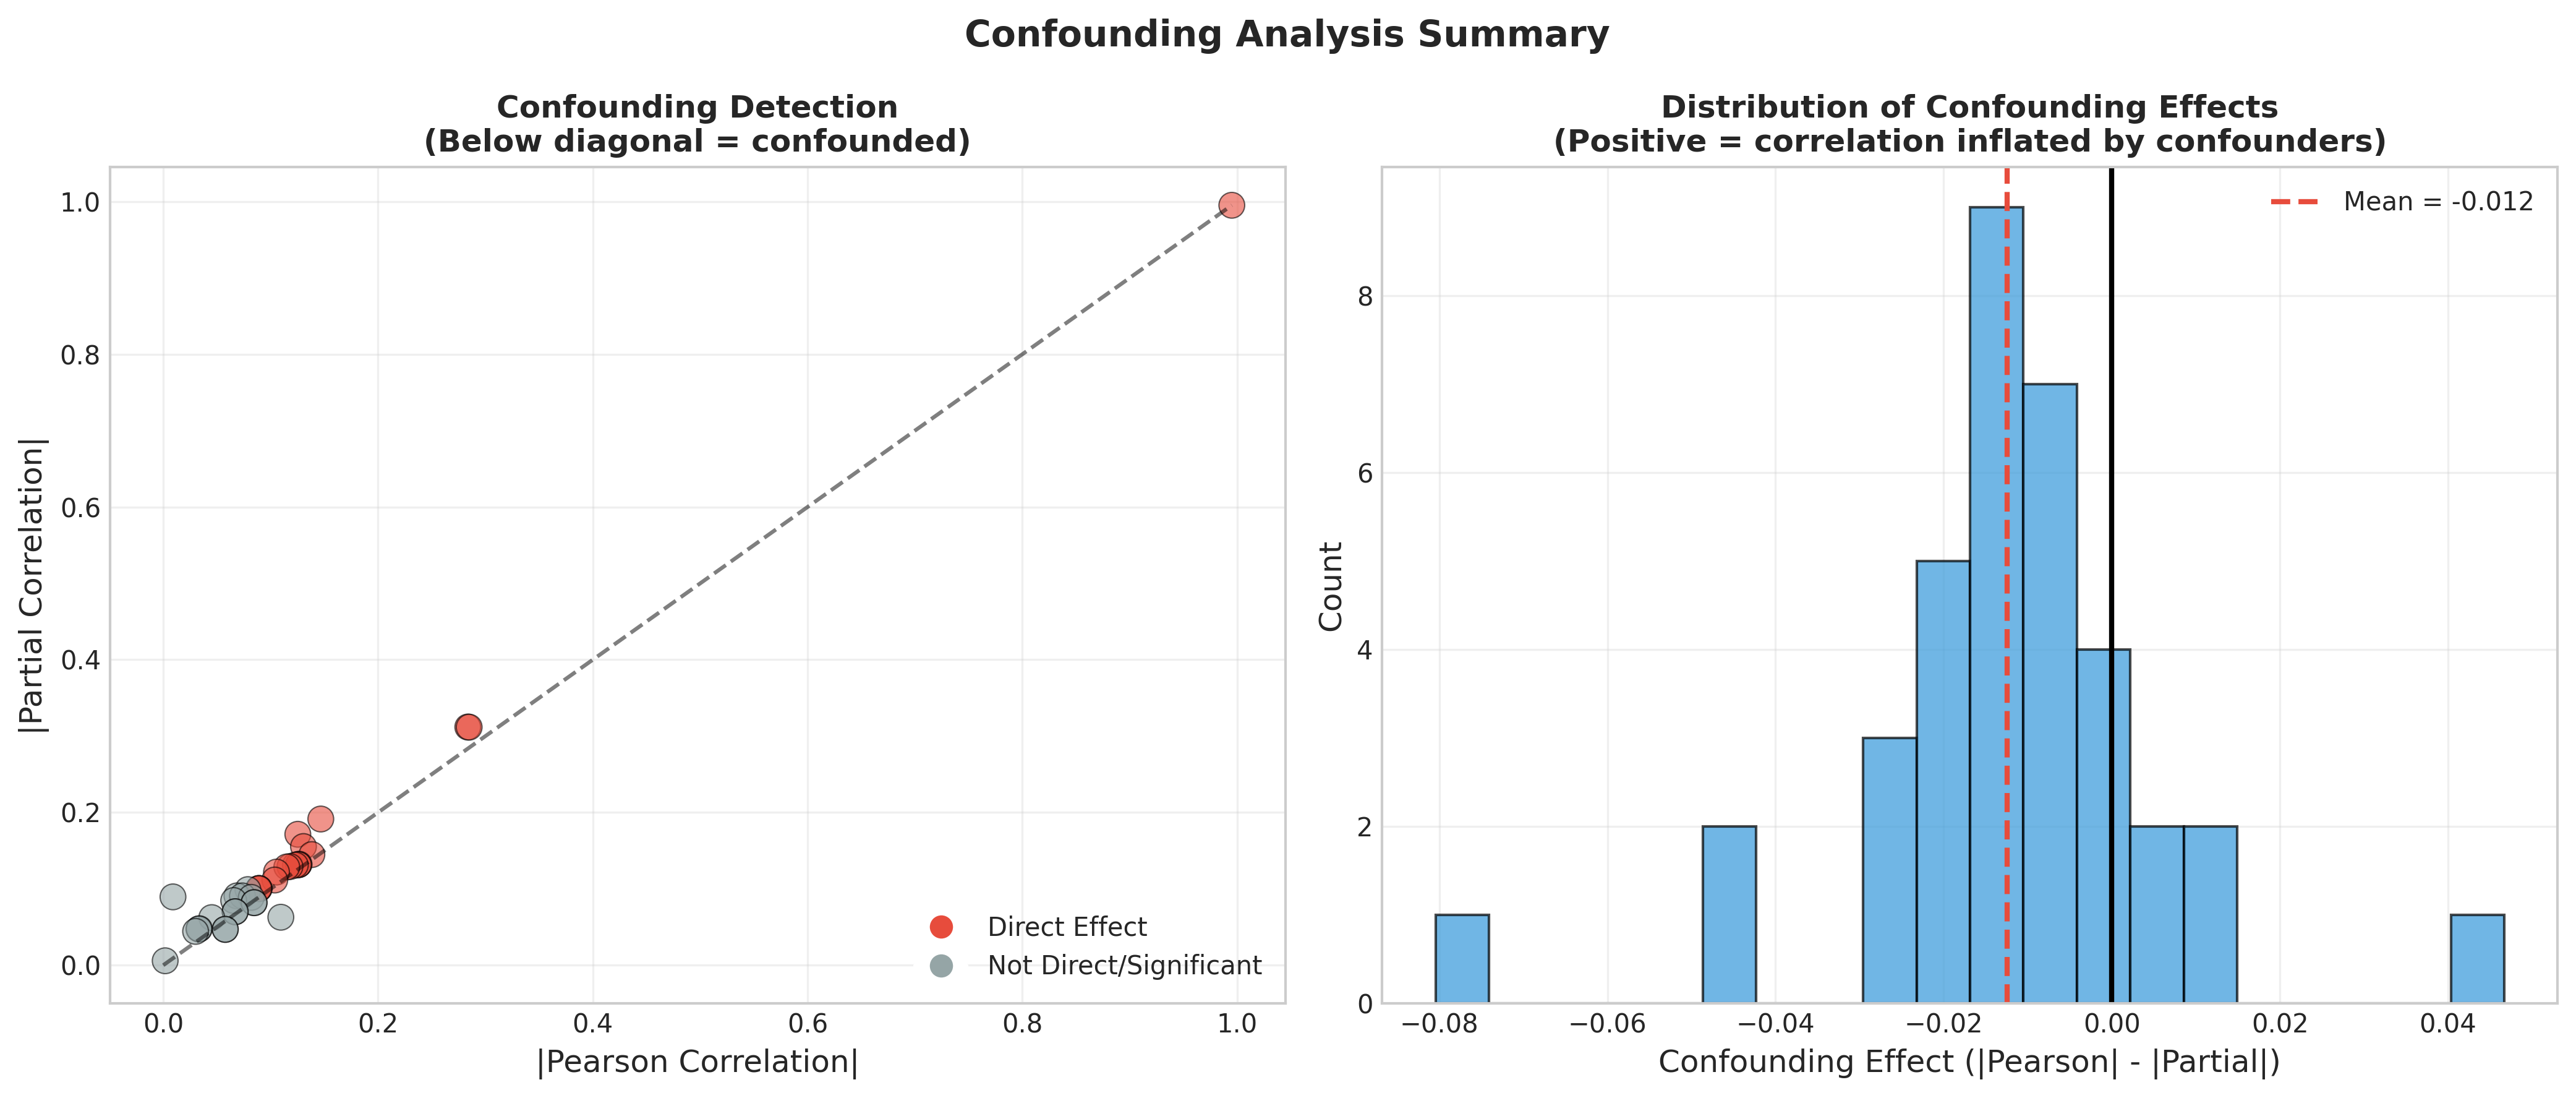

In [14]:
Image(filename=os.path.join(viz_dir, 'confounding_analysis.png'))


## 2. Multiple Regression Analysis

In [38]:
# Multiple Regression Analysis - Setup
regression_analyzer = MultipleRegressionAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    vif_threshold=10.0,
    significance_threshold=0.05,
    standardize=True,
    bootstrap_samples=1000
)

reg_prepared_data = regression_analyzer.prepare_data(data)
print("Data prepared for regression analysis")


2026-01-29 18:04:27 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - MultipleRegressionAnalyzer initialized for system: marconi100
2026-01-29 18:04:27 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - VIF threshold: 10.0, Standardize: True
2026-01-29 18:04:27 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Preparing data for multiple regression analysis...
2026-01-29 18:04:27 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Prepared data: 3 inputs, 11 outputs, 1 datacenter outputs


Data prepared for regression analysis


In [39]:

# Multiple Regression Analysis - Compute
print("Performing multiple regression analysis...")
regression_df = regression_analyzer.analyze_multiple_regression(reg_prepared_data)

print(f"\nOutputs analyzed: {len(regression_df)}")
print(f"Mean R²: {regression_df['r2'].mean():.3f}")
print(f"Well-explained outputs (R² > 0.7): {(regression_df['r2'] > 0.7).sum()}")

# Display best models
top_models = regression_df.nlargest(5, 'r2')
print("\nTop 5 Best Explained Outputs:")
print(top_models[['output', 'r2', 'adj_r2', 'f_statistic', 'f_pvalue']])


2026-01-29 18:04:28 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Performing multiple regression analysis...
2026-01-29 18:04:28 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Initializing Dask cluster for multiple regression analysis...
2026-01-29 18:04:28 - distributed.scheduler - INFO - State start
2026-01-29 18:04:28 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:45915
2026-01-29 18:04:28 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:35699/status
2026-01-29 18:04:28 - distributed.scheduler - INFO - Registering Worker plugin shuffle


Performing multiple regression analysis...


2026-01-29 18:04:28 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:46871'
2026-01-29 18:04:28 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:35263'
2026-01-29 18:04:28 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:43851'
2026-01-29 18:04:28 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:45459'
2026-01-29 18:04:28 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:37959'
2026-01-29 18:04:28 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:46781'
2026-01-29 18:04:28 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:41609'
2026-01-29 18:04:28 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:46653'
2026-01-29 18:04:28 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:35653'
2026-01-29 18:04:28 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:42635'
2026-01-29 18:04:28 - distribu


Outputs analyzed: 12
Mean R²: 0.122
Well-explained outputs (R² > 0.7): 1

Top 5 Best Explained Outputs:
             output        r2    adj_r2    f_statistic      f_pvalue
11              pue  0.990292  0.990288  244672.537779  1.110223e-16
7     p_prim_s_psig  0.127362  0.126998     350.087503  1.110223e-16
3        T_prim_s_C  0.121174  0.120808     330.733593  1.110223e-16
0   V_flow_prim_GPM  0.035459  0.035057      88.181359  1.110223e-16
4        T_prim_r_C  0.034004  0.033601      84.435930  1.110223e-16


2026-01-29 18:07:24 - distributed.scheduler - INFO - Remove client Client-ddf8edcb-fd66-11f0-80ba-0a580a221eb4
2026-01-29 18:07:24 - distributed.core - INFO - Received 'close-stream' from tcp://127.0.0.1:48334; closing.
2026-01-29 18:07:24 - distributed.scheduler - INFO - Remove client Client-ddf8edcb-fd66-11f0-80ba-0a580a221eb4
2026-01-29 18:07:25 - distributed.scheduler - INFO - Close client connection: Client-ddf8edcb-fd66-11f0-80ba-0a580a221eb4
2026-01-29 18:17:24 - distributed.core - INFO - Event loop was unresponsive in Nanny for 3.37s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-01-29 18:17:26 - distributed.core - INFO - Event loop was unresponsive in Nanny for 4.25s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-01-29 18:17:26 - distributed.core - INFO - Event loop was unresponsive in Nanny for 

In [40]:

# Multiple Regression - Detailed Results
# Extract beta coefficients for a specific output
example_output = KEY_OUTPUTS[0]
output_data = regression_df[regression_df['output'] == example_output].iloc[0]

print(f"\nRegression Model for {example_output}:")
print(f"R² = {output_data['r2']:.4f}")
print(f"Adjusted R² = {output_data['adj_r2']:.4f}")
print(f"F-statistic = {output_data['f_statistic']:.2f} (p = {output_data['f_pvalue']:.4e})")

print("\nBeta Coefficients:")
for input_var in ['Q_flow', 'T_Air', 'T_ext']:
    beta = output_data.get(f'beta_{input_var}', np.nan)
    pval = output_data.get(f'pvalue_{input_var}', np.nan)
    vif = output_data.get(f'vif_{input_var}', np.nan)
    print(f"  {input_var}: β = {beta:.4f}, p = {pval:.4e}, VIF = {vif:.2f}")



Regression Model for T_sec_r_C:
R² = 0.0268
Adjusted R² = 0.0264
F-statistic = 66.03 (p = 1.1102e-16)

Beta Coefficients:
  Q_flow: β = -0.0440, p = 1.1909e-05, VIF = 1.01
  T_Air: β = -0.1311, p = 0.0000e+00, VIF = 1.00
  T_ext: β = 0.1003, p = 2.2204e-16, VIF = 1.02


2026-01-29 18:04:37 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Extracting beta coefficient matrix...
2026-01-29 18:04:37 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Extracting significance matrix...
2026-01-29 18:04:37 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Computing VIF summary...
2026-01-29 18:04:37 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Computing variance explained summary...
2026-01-29 18:04:37 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.regression_visualizer - INFO - Creating beta coefficient plot...
2026-01-29 18:04:38 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.regression_visualizer - INFO - Created beta coefficient plot
2026-01-29 18:04:38 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.regression_visualizer - INFO - Creating 

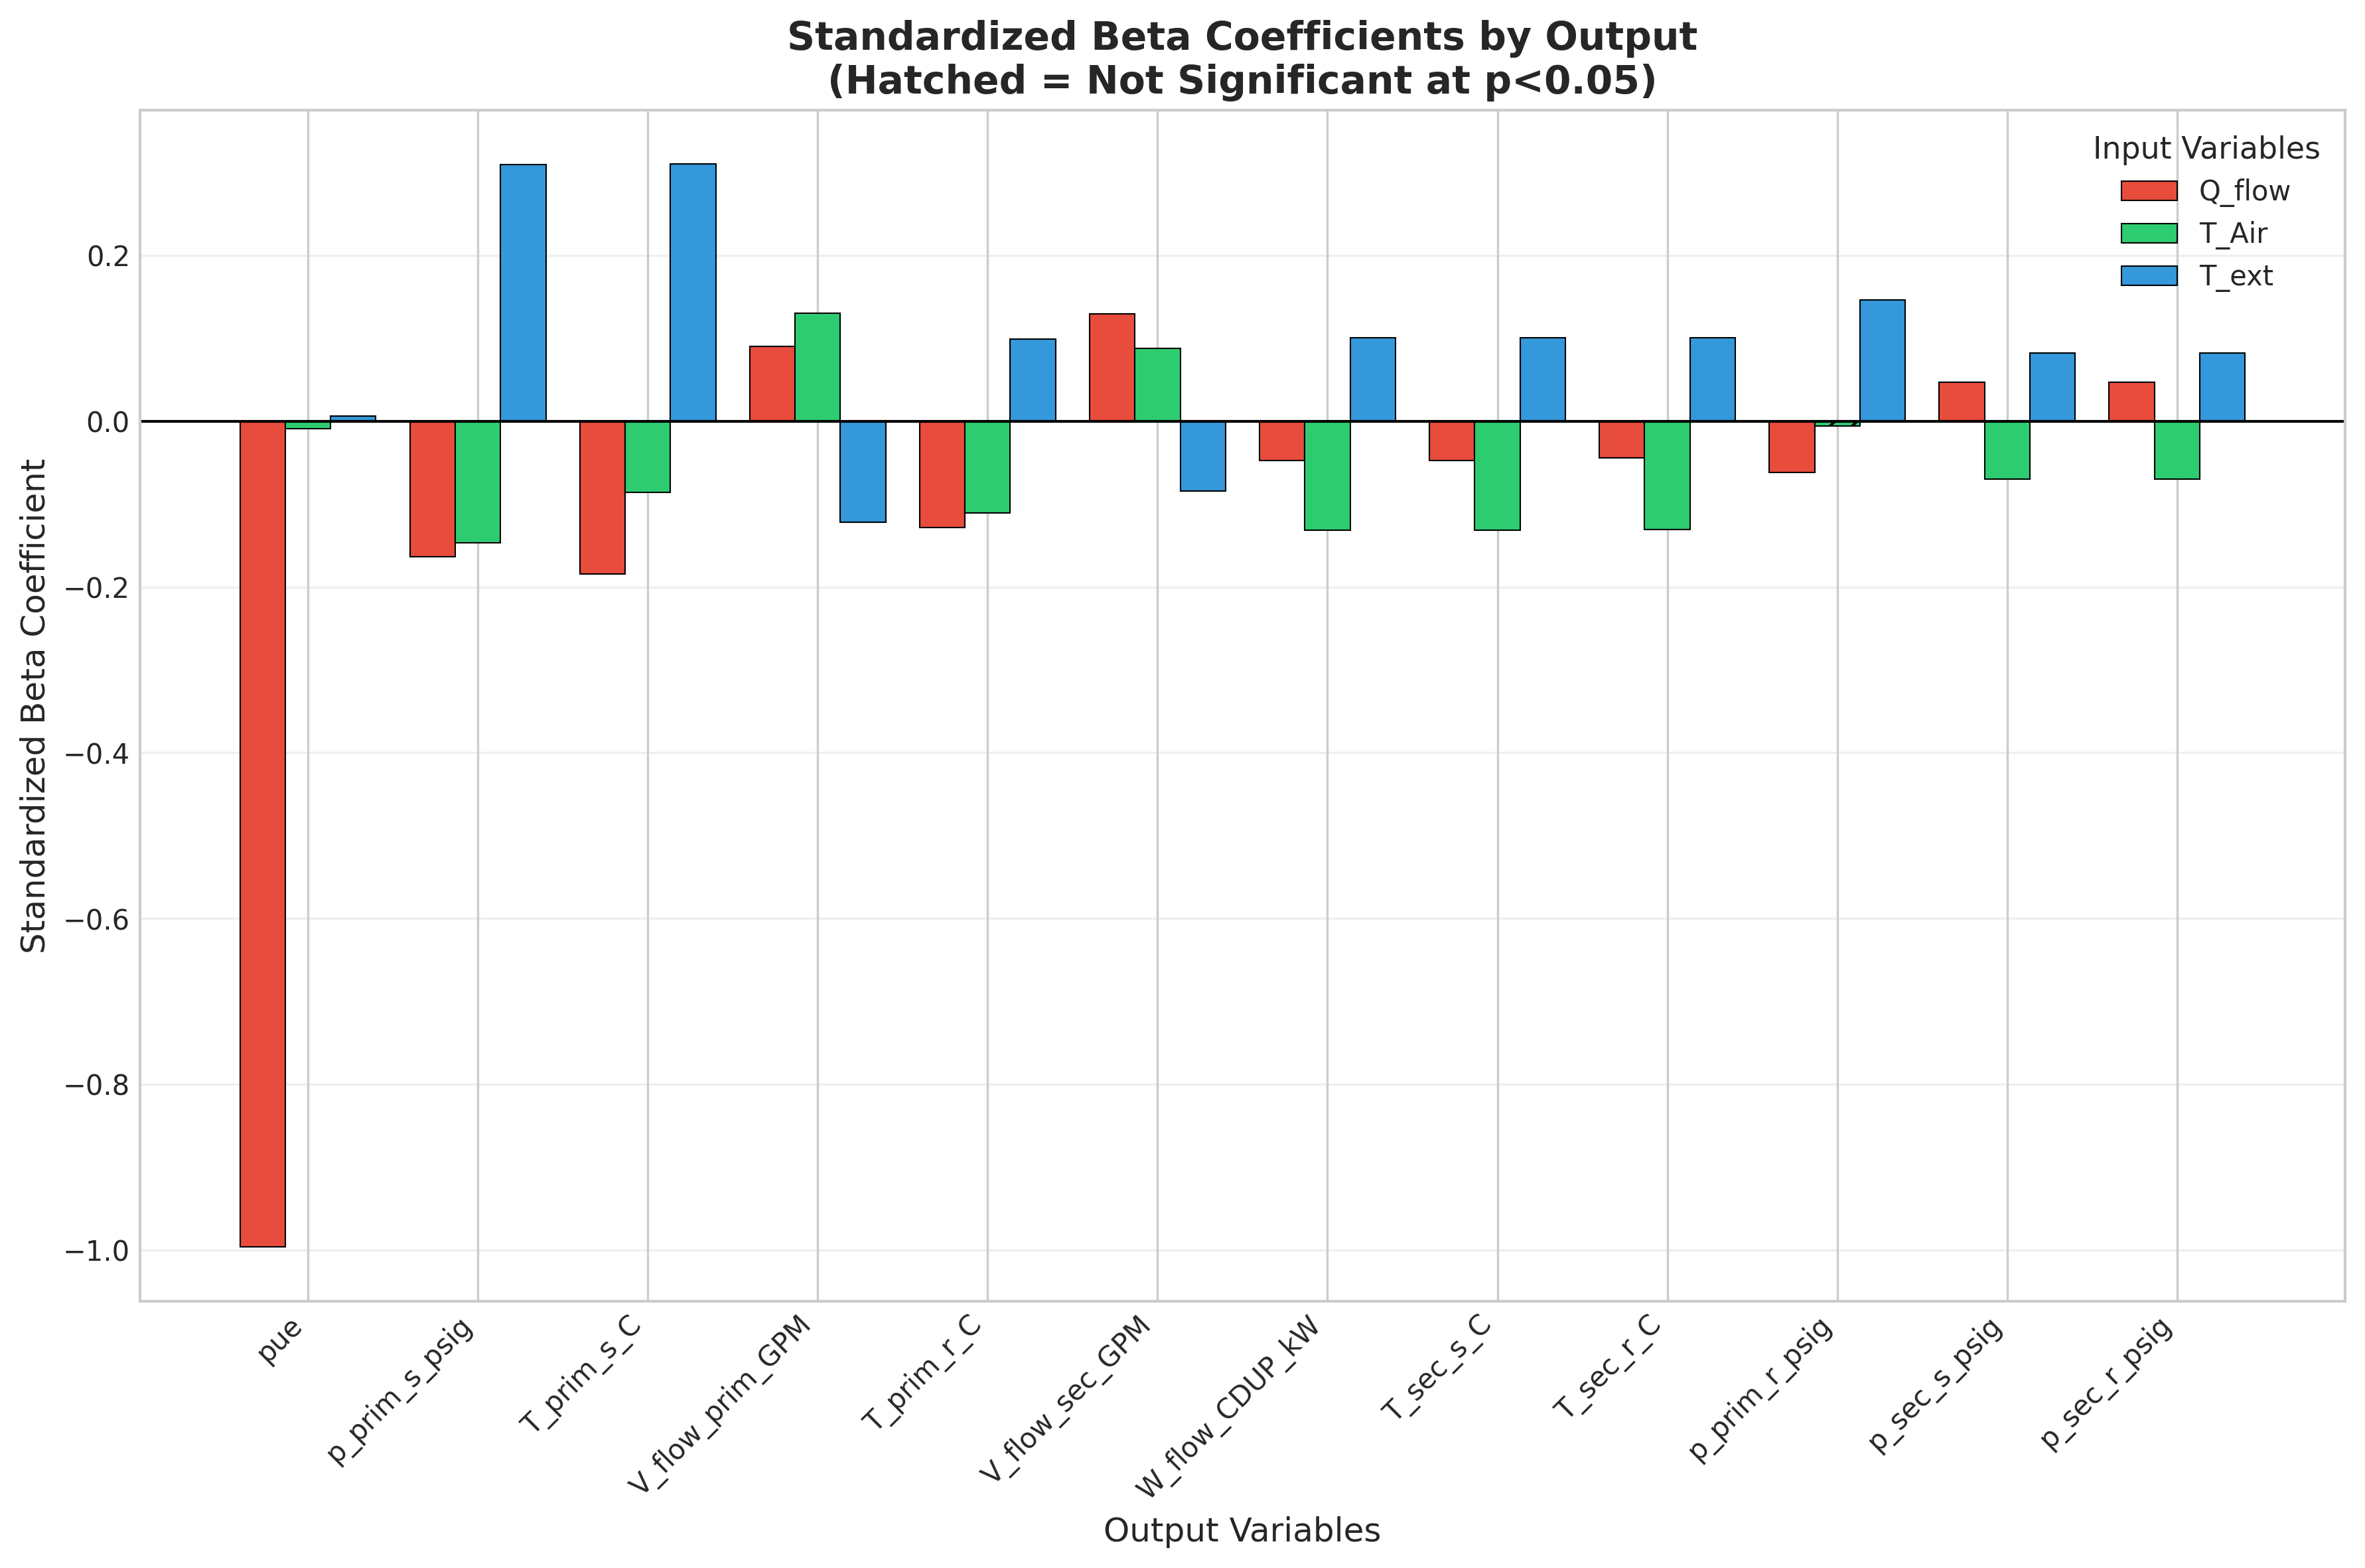

In [41]:
# Multiple Regression - Visualizations
beta_matrix = regression_analyzer.compute_beta_coefficient_matrix(regression_df)
pvalue_matrix = regression_analyzer.compute_significance_matrix(regression_df)
vif_summary = regression_analyzer.compute_vif_summary(regression_df)
variance_df = regression_analyzer.compute_variance_explained(regression_df)

viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'regression')
os.makedirs(viz_dir, exist_ok=True)

create_beta_coefficient_plot(regression_df, viz_dir)
create_significance_heatmap(pvalue_matrix, viz_dir)
create_variance_explained_chart(variance_df, viz_dir)
create_vif_plot(vif_summary, viz_dir, threshold=10.0)
create_regression_summary_plot(regression_df, viz_dir)

Image(filename=os.path.join(viz_dir, 'beta_coefficients.png'))


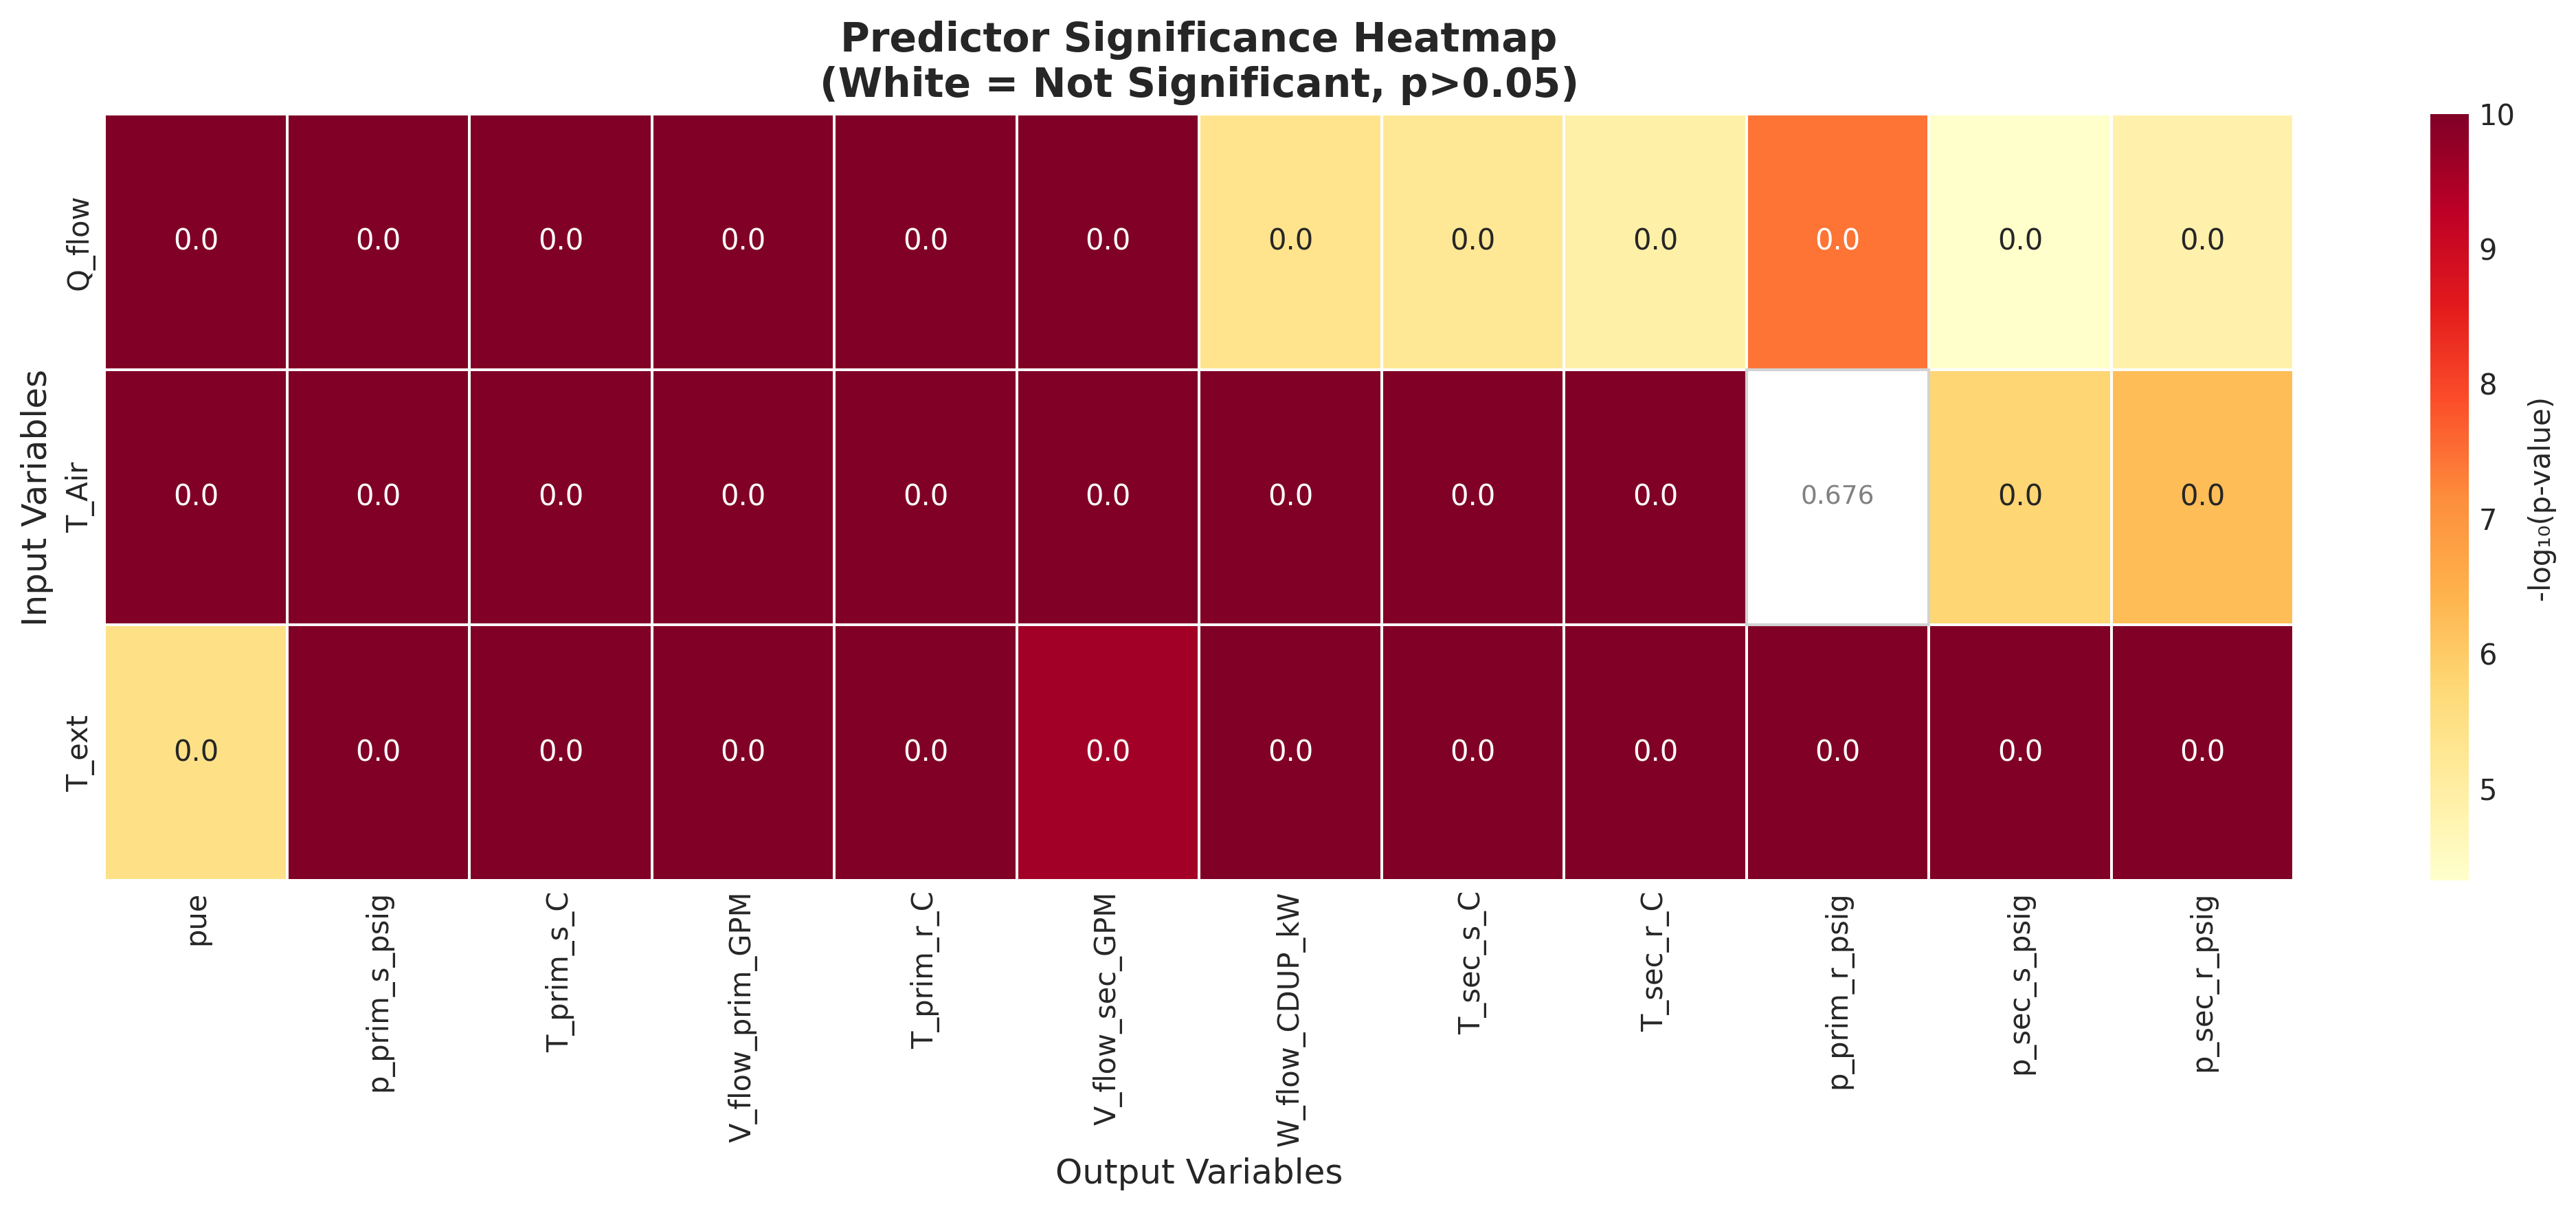

In [16]:
Image(filename=os.path.join(viz_dir, 'significance_heatma.png'))


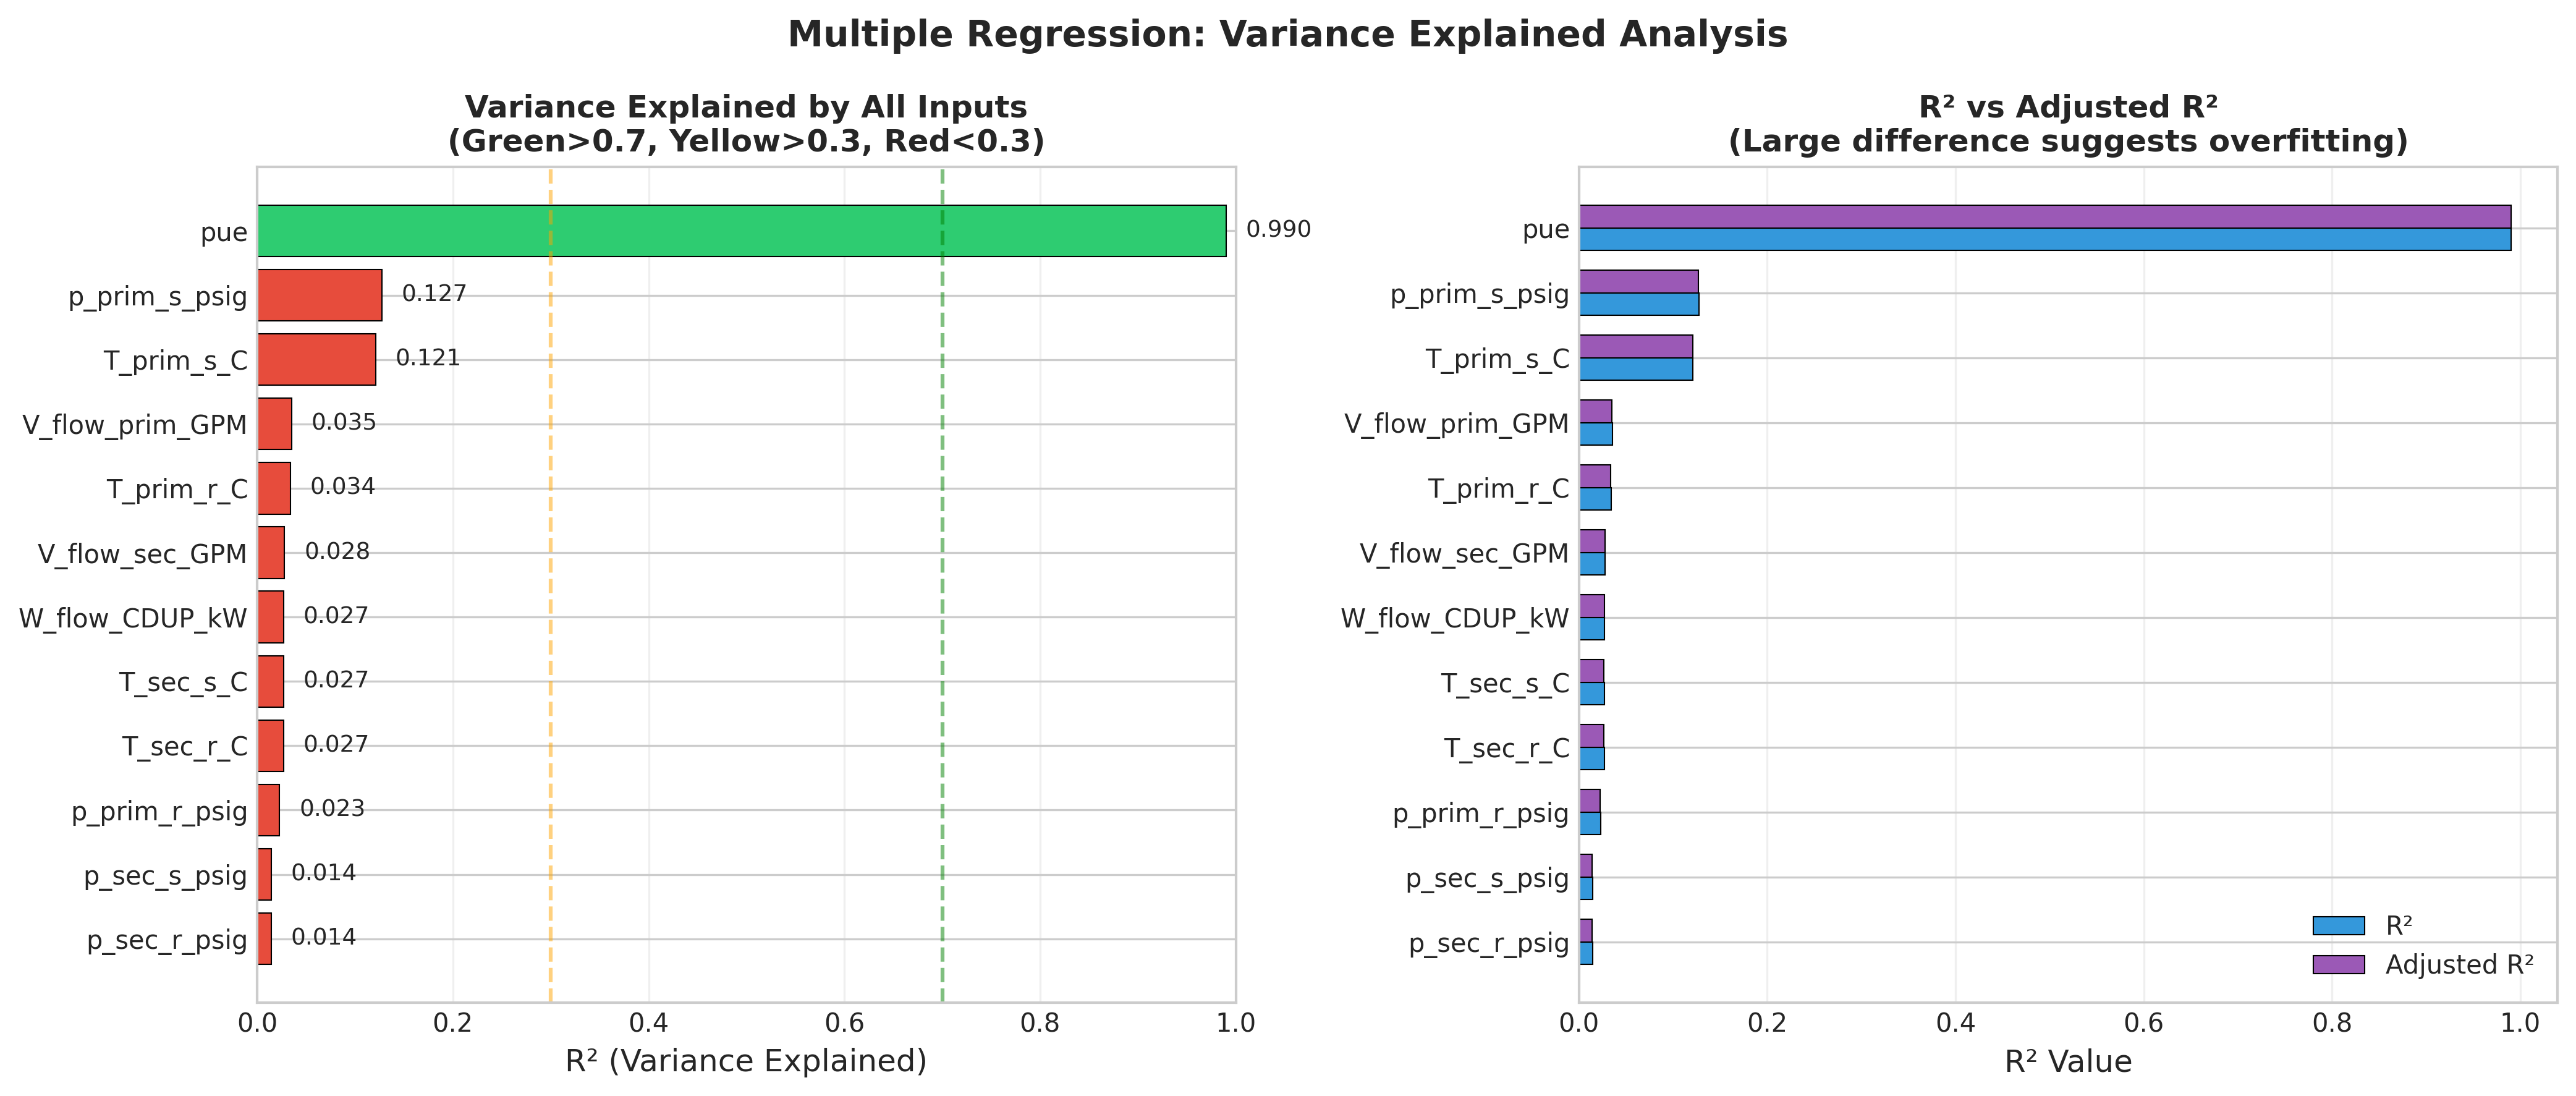

In [17]:
Image(filename=os.path.join(viz_dir, 'variance_explained.png'))


## 3. Lagged Effect Analysis

In [7]:

#  Lagged Effect Analysis - Setup
lagged_analyzer = LaggedEffectAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    max_lag=MAX_LAG*40,
    min_lag=0,
    lag_step=5,
    cv_folds=5,
    significance_threshold=0.05
)

lag_prepared_data = lagged_analyzer.prepare_data(data)
print(f"Data prepared for lagged analysis. Max lag: {MAX_LAG*40}")


2026-02-05 06:16:23 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - LaggedEffectAnalyzer initialized for system: marconi100
2026-02-05 06:16:23 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Max lag: 1200, Lag step: 5
2026-02-05 06:16:23 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Preparing data for lagged effect analysis...
2026-02-05 06:16:23 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Prepared data: 3 inputs, 11 outputs


Data prepared for lagged analysis. Max lag: 30


In [ ]:

# Lagged Effect Analysis - Compute
print("Analyzing lagged effects (this may take a while)...")
lag_df = lagged_analyzer.analyze_lagged_effects(lag_prepared_data)

print(f"\nRelationships analyzed: {len(lag_df)}")
print(f"Need sequence inputs: {lag_df['needs_sequence_input'].sum()}")
print(f"Average memory length: {lag_df['memory_length'].mean():.1f} lags")

# Display relationships needing sequences
needs_seq = lag_df[lag_df['needs_sequence_input']]
print(f"\nTop relationships requiring sequence inputs:")
print(needs_seq.nlargest(5, 'optimal_lag')[['input', 'output', 'optimal_lag', 'memory_length']])


In [9]:
# Lagged Effect Analysis - Summaries
cumulative_df = lagged_analyzer.compute_cumulative_effects(lag_df)
memory_summary = lagged_analyzer.get_memory_length_summary(lag_df)

print("Memory Length Summary:")
print(memory_summary)

print("\nCumulative Effects (sample):")
print(cumulative_df.head(10))


2026-02-05 06:51:45 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Computing cumulative effects...
2026-02-05 06:51:45 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Computing memory length summary...


Memory Length Summary:
    input  mean_memory_length  max_memory_length  mean_optimal_lag  \
0  Q_flow               500.0               1200         15.416667   
1   T_Air              1000.0               1200          1.666667   
2   T_ext               700.0               1200        653.750000   

   pct_needs_sequence  mean_r2_improvement  
0            8.333333             0.216460  
1           75.000000             0.234787  
2            8.333333             0.566681  

Cumulative Effects (sample):
    input           output  lag  coefficient  cumulative_effect
0  Q_flow  V_flow_prim_GPM    0     1.038673           1.038673
1  Q_flow  V_flow_prim_GPM    5    -1.062828          -0.024155
2  Q_flow  V_flow_prim_GPM   10     0.070194           0.046040
3  Q_flow  V_flow_prim_GPM   15    -0.011726           0.034314
4  Q_flow  V_flow_prim_GPM   20    -0.007403           0.026910
5  Q_flow  V_flow_prim_GPM   25    -0.012608           0.014303
6  Q_flow  V_flow_prim_GPM   30    -0.

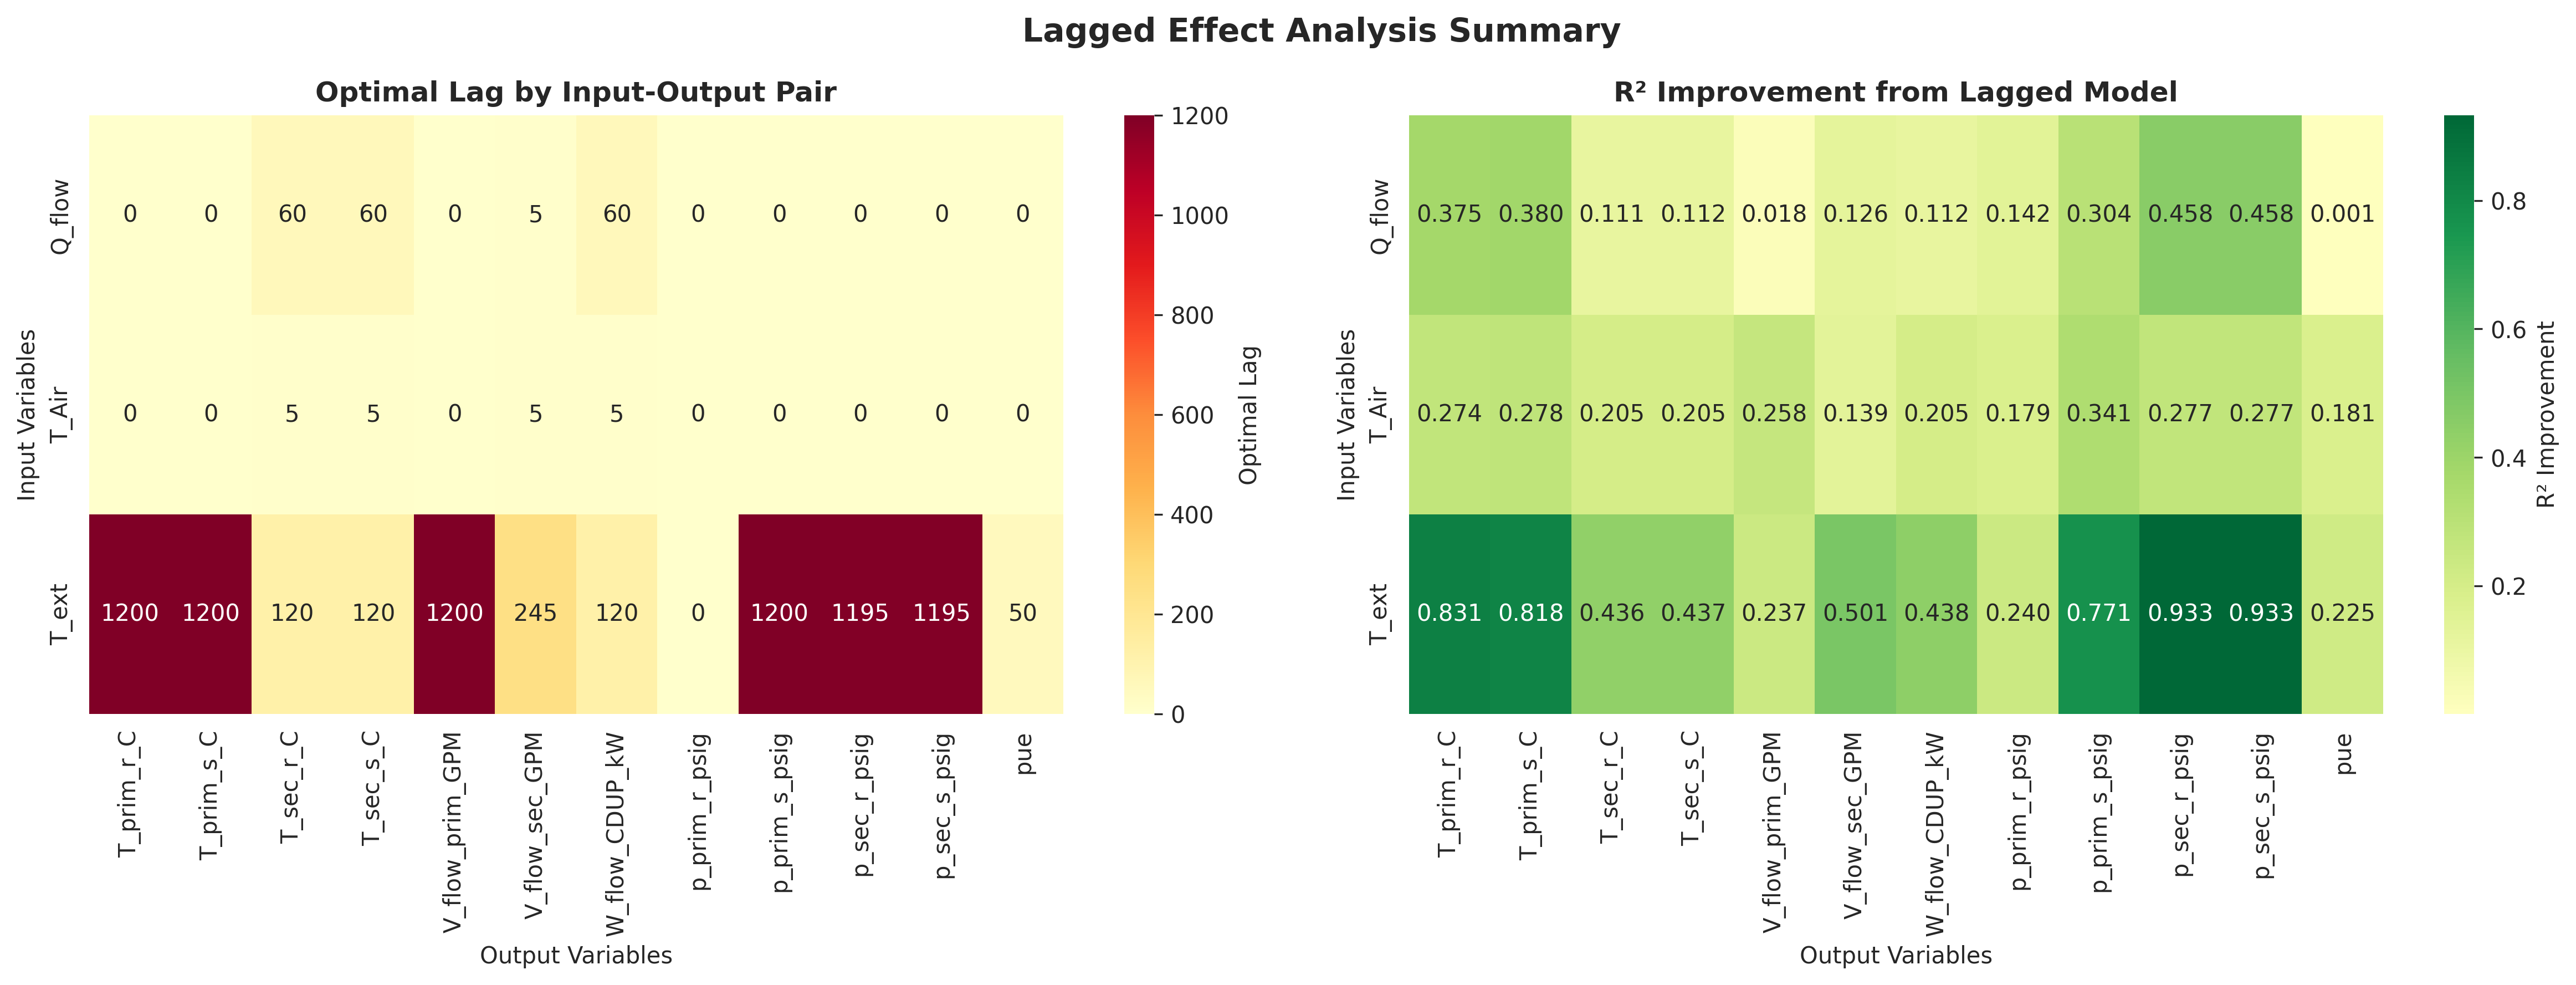

In [13]:
#  Lagged Effect - Visualizations
viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'lagged_effects')
os.makedirs(viz_dir, exist_ok=True)

if hasattr(lagged_analyzer, '_full_lag_results'):
    create_lag_coefficient_plots(
        lagged_analyzer._full_lag_results,
        viz_dir,
        n_workers=N_WORKERS
    )

create_lag_heatmap(lag_df, viz_dir)
create_memory_length_plot(memory_summary, viz_dir)
create_cumulative_effect_summary(cumulative_df, viz_dir)
create_lag_analysis_summary(lag_df, viz_dir)

Image(filename=os.path.join(viz_dir, 'lag_heatmap.png'))


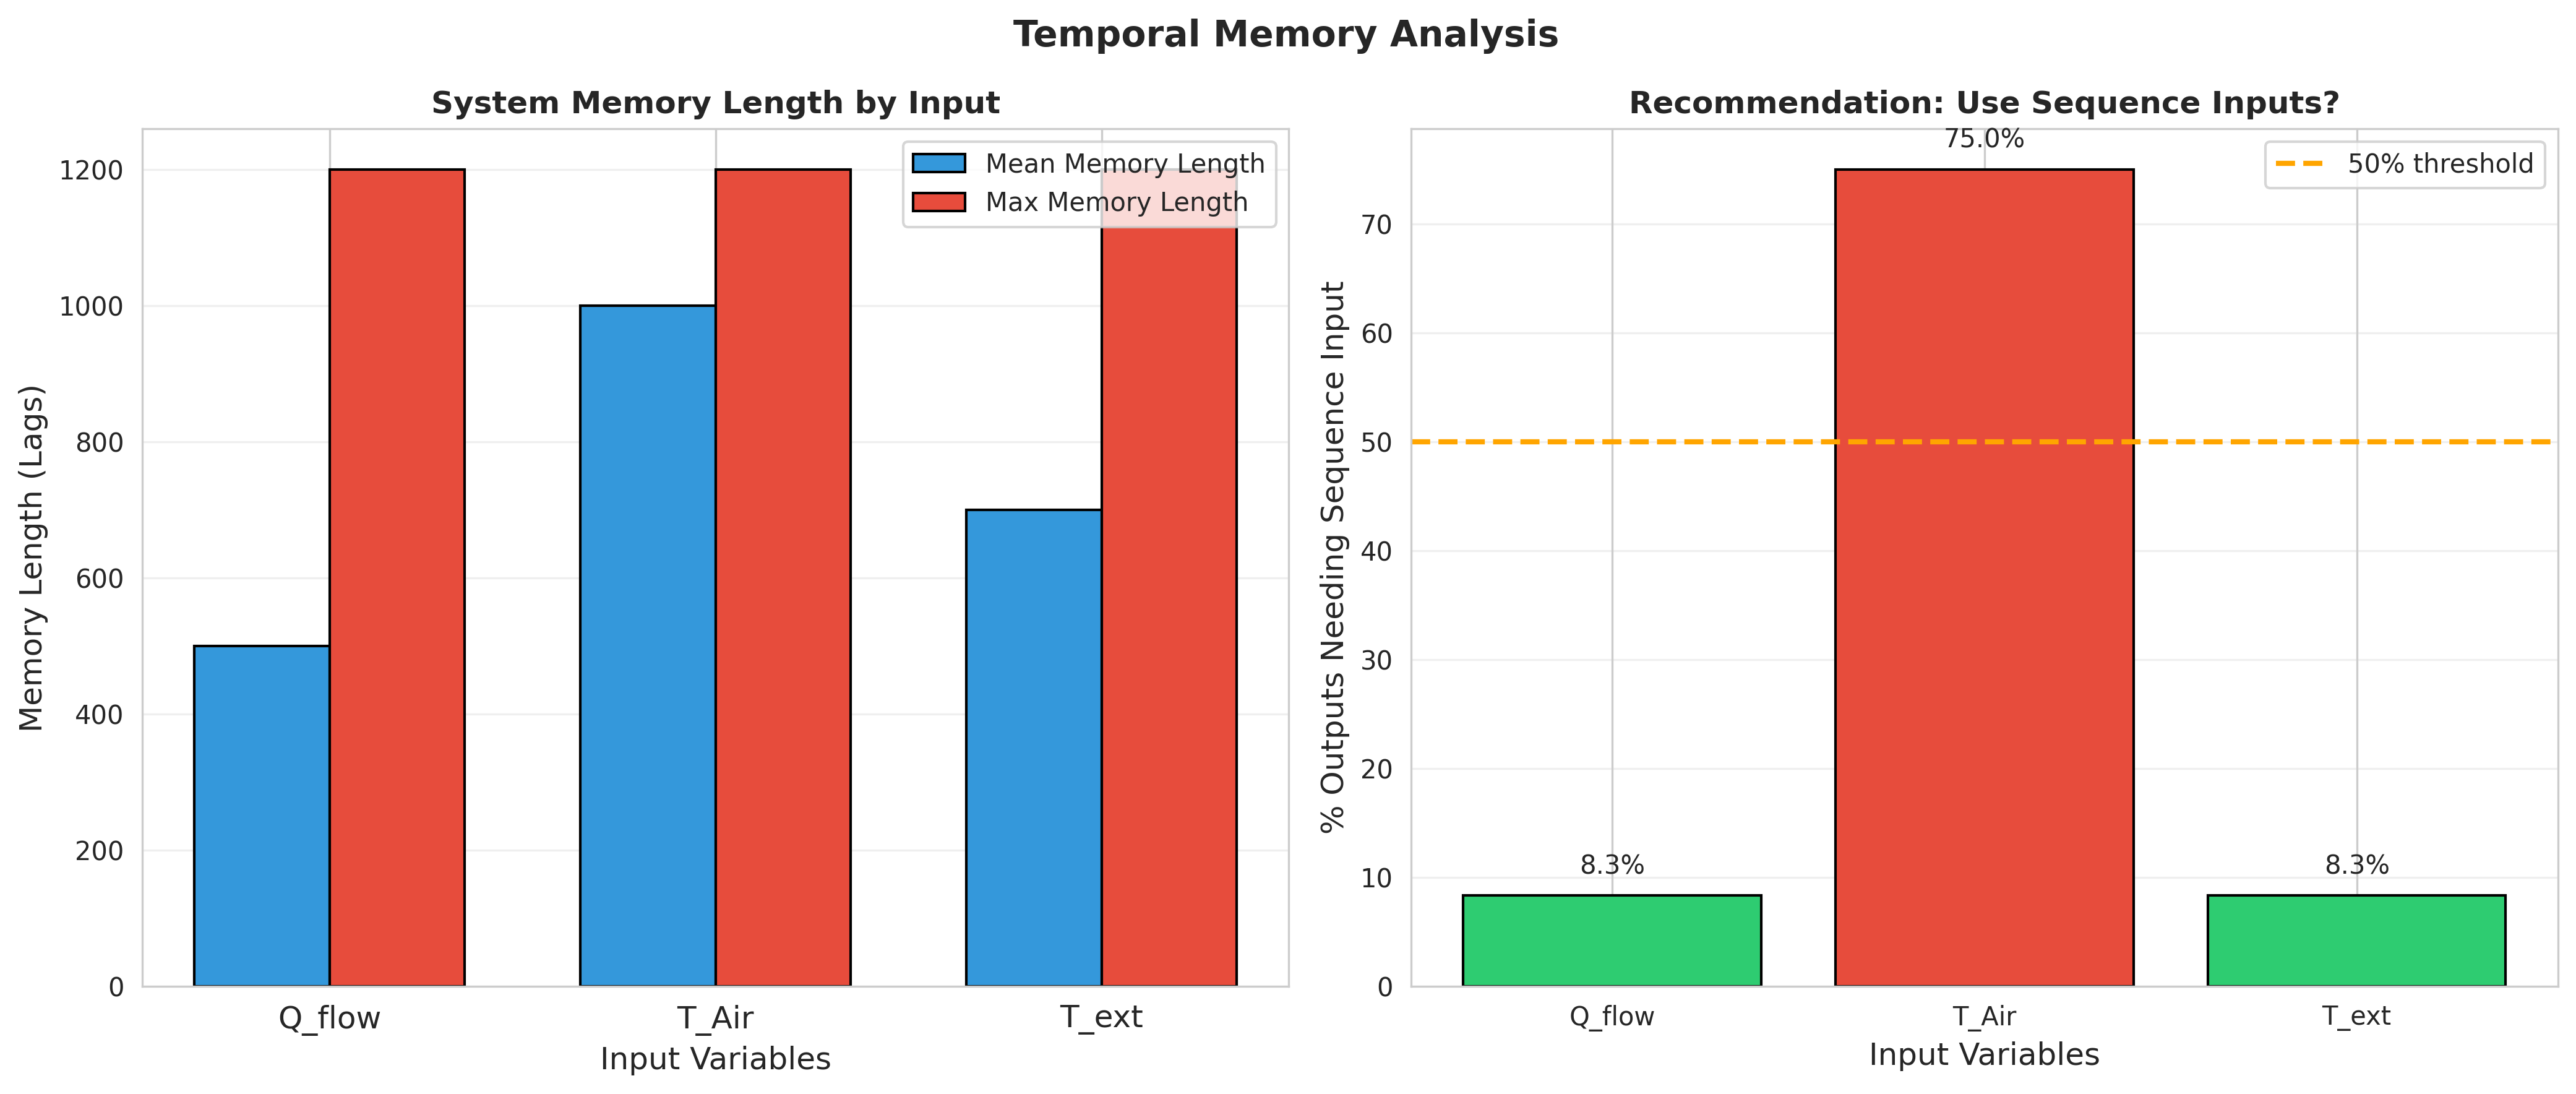

In [14]:
Image(filename=os.path.join(viz_dir, 'memory_length.png'))


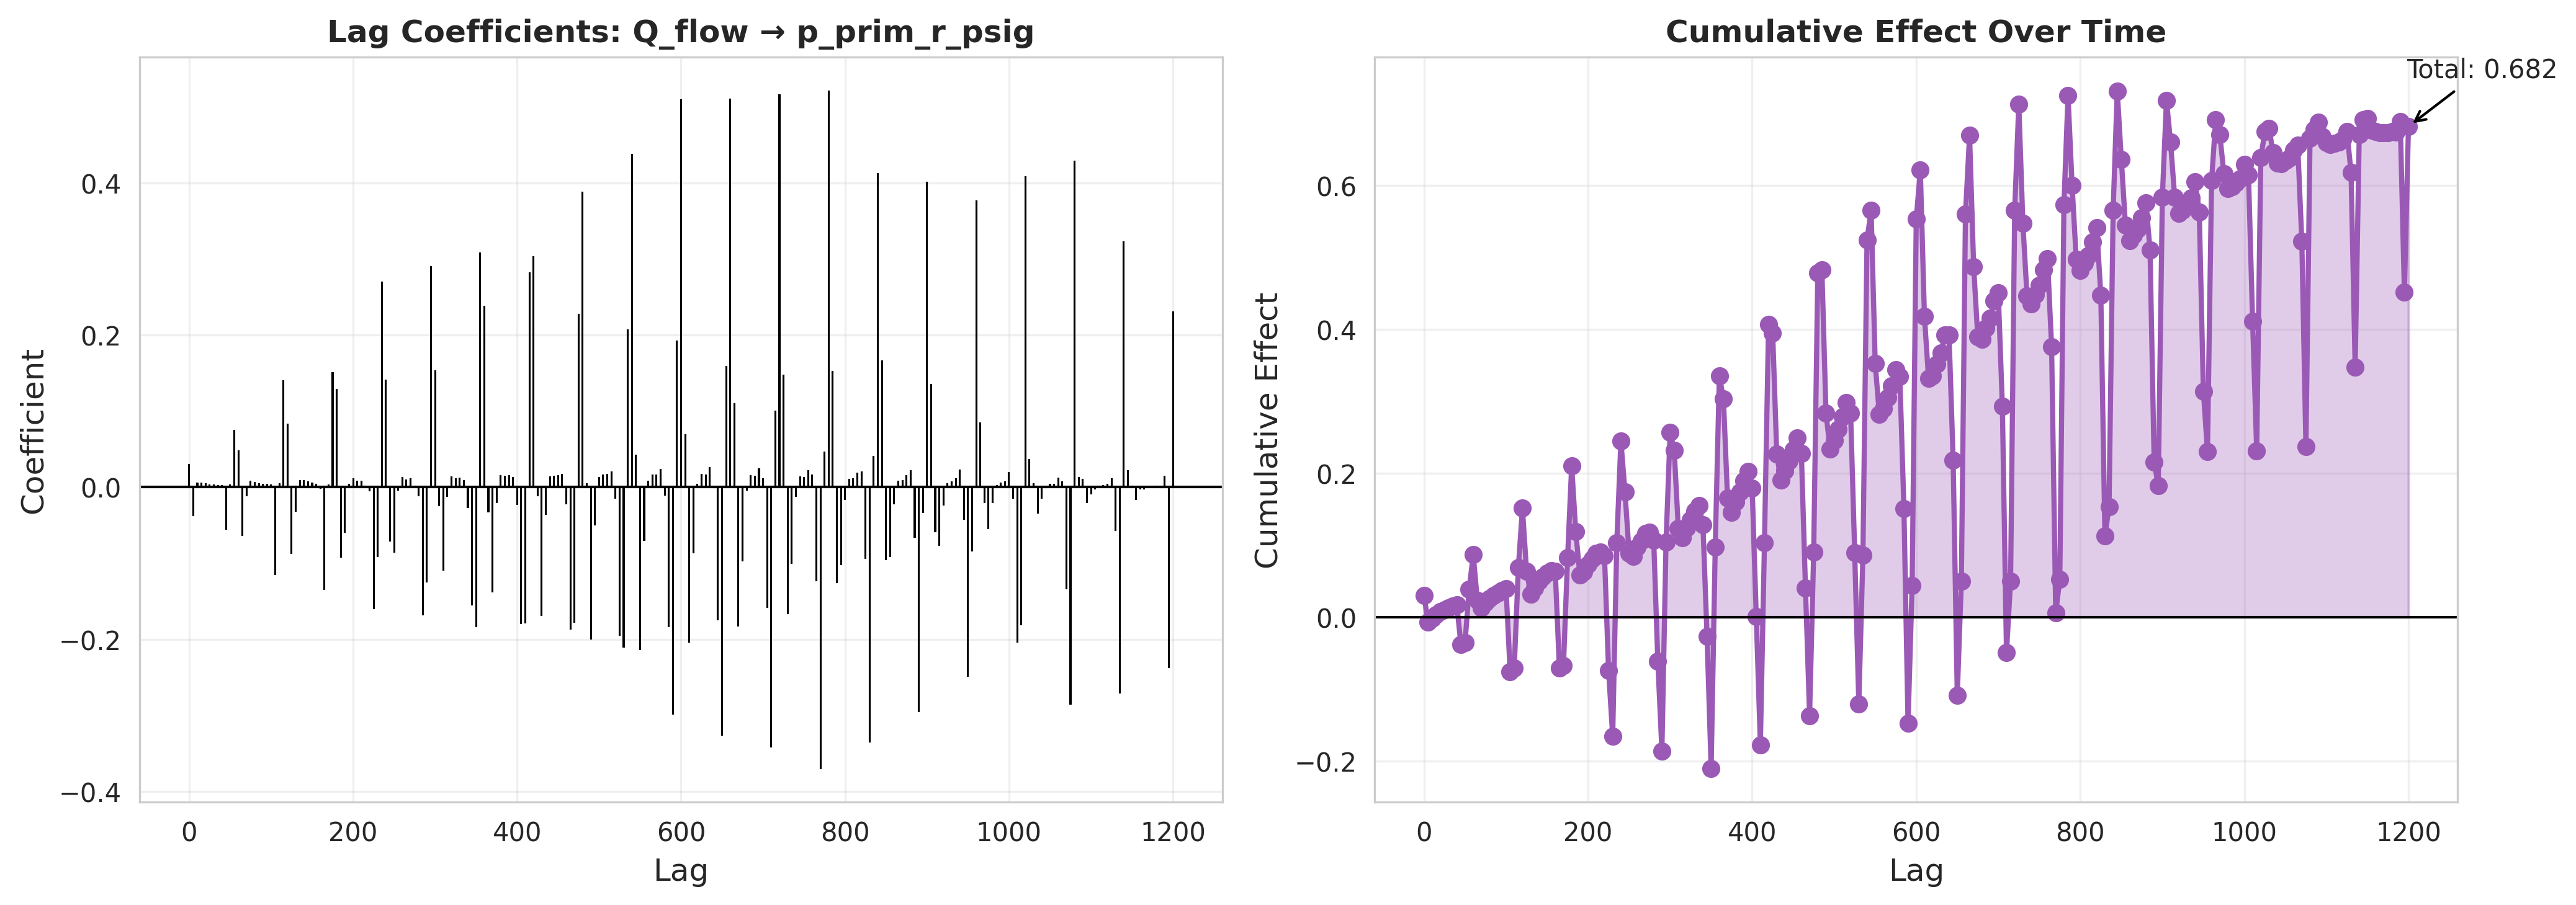

In [11]:
Image(filename=os.path.join(viz_dir, 'lag_coefficients_Q_flow_p_prim_r_psig.png'))


## 4. AutoCorrelation Analysis

In [76]:
#  Autocorrelation Analysis - Setup
autocorr_analyzer = AutocorrelationAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    max_lag=1500,
    confidence_level=0.95,
    compute_pacf=True,
    compute_ccf=True
)

autocorr_prepared_data = autocorr_analyzer.prepare_data(data)
print("Data prepared for autocorrelation analysis")


2026-01-29 18:21:34 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - AutocorrelationAnalyzer initialized for system: marconi100
2026-01-29 18:21:34 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Max lag: 1500, Confidence level: 0.95
2026-01-29 18:21:34 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Preparing data for autocorrelation analysis...
2026-01-29 18:21:34 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Prepared data: 3 inputs, 11 outputs


Data prepared for autocorrelation analysis


In [ ]:
#   Autocorrelation Analysis - ACF/PACF
print("Computing ACF and PACF...")
input_acf_df, output_acf_df = autocorr_analyzer.analyze_autocorrelation(autocorr_prepared_data)

print(f"\nInput ACF results: {len(input_acf_df)} variables")
print(f"Output ACF results: {len(output_acf_df)} variables")


In [78]:
input_acf_df

,variable,first_insignificant_lag,persistence,ar_order_suggestion,n_significant_acf_lags,n_significant_pacf_lags
0,Q_flow,81,147.443780,1153,1312,49
1,T_Air,91,107.427038,1456,996,68
2,T_ext,74,131.726732,1394,1230,32


In [80]:
output_acf_df

,variable,first_insignificant_lag,persistence,ar_order_suggestion,n_significant_acf_lags,n_significant_pacf_lags
0,V_flow_prim_GPM,1184.0,626.118273,24,1371,24
1,V_flow_sec_GPM,NaN,553.993859,1212,1500,49
2,W_flow_CDUP_kW,NaN,1059.679850,1,1500,1
3,T_prim_s_C,NaN,692.931709,18,1500,18
4,T_prim_r_C,NaN,836.767718,1,1500,1
5,T_sec_s_C,NaN,1060.858695,1,1500,1
6,T_sec_r_C,NaN,1061.260977,1,1500,1
7,p_prim_s_psig,NaN,664.508983,5,1500,5
8,p_prim_r_psig,NaN,879.741712,1,1500,1
9,p_sec_s_psig,NaN,555.216496,7,1500,7


In [81]:

# Autocorrelation Analysis - Cross-Correlation
print("Computing cross-correlations...")
ccf_df = autocorr_analyzer.analyze_cross_correlation(autocorr_prepared_data)

print(f"\nCross-correlations computed: {len(ccf_df)}")

# Show strongest cross-correlations
ccf_df['abs_max_ccf'] = ccf_df['peak_ccf'].abs()
top_ccf = ccf_df.nlargest(10, 'abs_max_ccf')
print("\nTop 10 Cross-Correlations:")
print(top_ccf[['input', 'output', 'peak_ccf', 'peak_lag', 'n_significant_lags']])


2026-01-29 18:24:28 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Analyzing cross-correlation patterns...
2026-01-29 18:24:28 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Executing 36 CCF analyses...


Computing cross-correlations...


2026-01-29 18:24:45 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Completed CCF analysis for 36 input-output pairs



Cross-correlations computed: 36

Top 10 Cross-Correlations:
     input          output  peak_ccf  peak_lag  n_significant_lags
11  Q_flow             pue -0.995078         0                2674
27   T_ext      T_prim_s_C  0.569801       -50                2558
34   T_ext    p_sec_r_psig  0.484896      -119                2635
33   T_ext    p_sec_s_psig  0.484888      -119                2635
31   T_ext   p_prim_s_psig  0.411143       -47                2728
25   T_ext  V_flow_sec_GPM  0.383566      -116                2623
28   T_ext      T_prim_r_C  0.354095      -103                2659
19   T_Air   p_prim_s_psig -0.317583      -443                2488
15   T_Air      T_prim_s_C -0.300933      -451                2498
20   T_Air   p_prim_r_psig -0.298762     -1500                2121


In [82]:

# Temporal Recommendations
recommendations_df = autocorr_analyzer.compute_temporal_recommendations(output_acf_df, ccf_df)

print(f"Temporal recommendations for {len(recommendations_df)} outputs")
print(f"Need temporal modeling: {recommendations_df['needs_temporal_model'].sum()}")

# Display recommendations
temporal_needed = recommendations_df[recommendations_df['needs_temporal_model']]
print("\nOutputs Requiring Temporal Models:")
for _, row in temporal_needed.iterrows():
    print(f"\n{row['output']}:")
    print(f"  {row['recommendation']}")


2026-01-29 18:24:45 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Computing temporal modeling recommendations...


Temporal recommendations for 12 outputs
Need temporal modeling: 12

Outputs Requiring Temporal Models:

V_flow_prim_GPM:
  Use LSTM or sequence model with 24 lags. High persistence (626.1) indicates strong temporal dependencies.

V_flow_sec_GPM:
  Use LSTM or sequence model with 1212 lags. High persistence (554.0) indicates strong temporal dependencies.

W_flow_CDUP_kW:
  Use LSTM or sequence model with 1 lags. High persistence (1059.7) indicates strong temporal dependencies.

T_prim_s_C:
  Use LSTM or sequence model with 18 lags. High persistence (692.9) indicates strong temporal dependencies.

T_prim_r_C:
  Use LSTM or sequence model with 1 lags. High persistence (836.8) indicates strong temporal dependencies.

T_sec_s_C:
  Use LSTM or sequence model with 1 lags. High persistence (1060.9) indicates strong temporal dependencies.

T_sec_r_C:
  Use LSTM or sequence model with 1 lags. High persistence (1061.3) indicates strong temporal dependencies.

p_prim_s_psig:
  Use LSTM or sequence

2026-01-29 18:24:55 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.autocorrelation_visualizer - INFO - Creating ACF/PACF plots in parallel...
2026-01-29 18:25:03 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.autocorrelation_visualizer - INFO - Created 15/15 ACF/PACF plots
2026-01-29 18:25:03 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.autocorrelation_visualizer - INFO - Creating CCF plots in parallel...
2026-01-29 18:25:13 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.autocorrelation_visualizer - INFO - Created 36/36 CCF plots
2026-01-29 18:25:13 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.autocorrelation_visualizer - INFO - Creating persistence summary...
2026-01-29 18:25:15 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.autocorrelation_visualizer - INFO - Created persistence summary
2026-01-29 18:25:15 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.autocorrelation_visualizer - INFO - Creating 

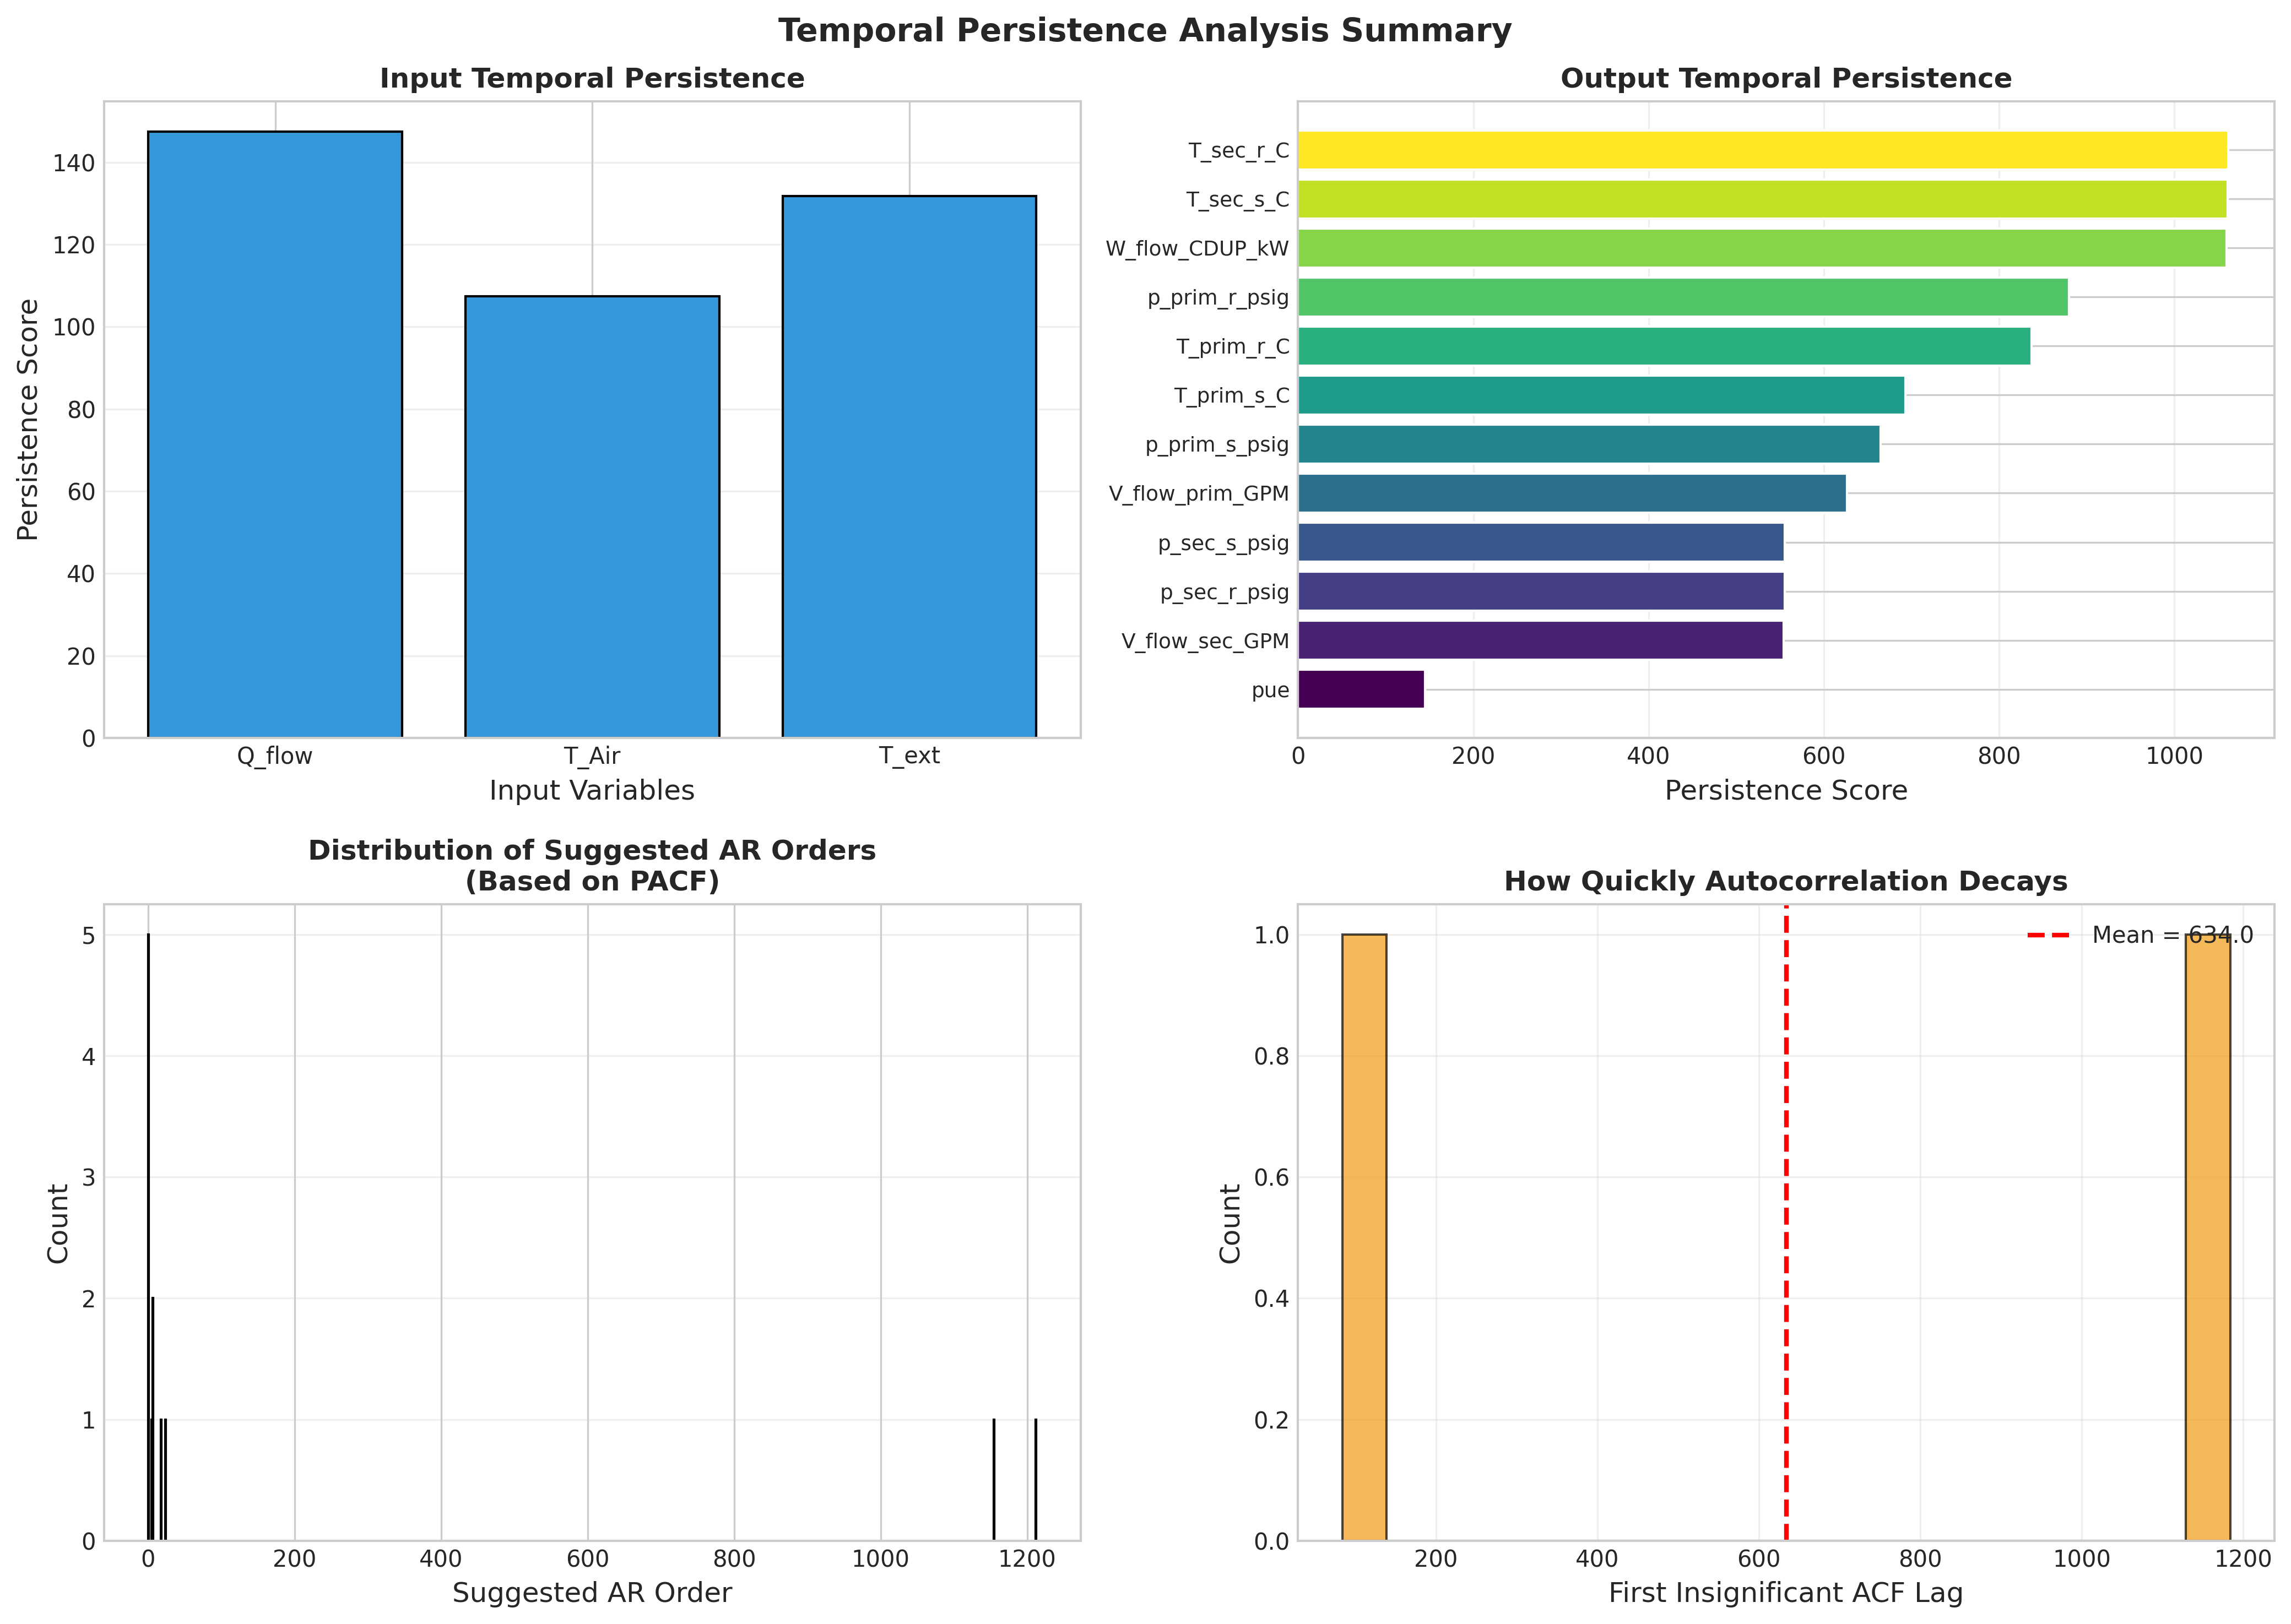

In [83]:

# Autocorrelation - Visualizations
viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'autocorrelation')
os.makedirs(viz_dir, exist_ok=True)

if hasattr(autocorr_analyzer, '_acf_results'):
    create_acf_plots(autocorr_analyzer._acf_results, viz_dir, n_workers=N_WORKERS)

if hasattr(autocorr_analyzer, '_ccf_results'):
    create_ccf_plots(autocorr_analyzer._ccf_results, viz_dir, n_workers=N_WORKERS)

create_persistence_summary(input_acf_df, output_acf_df, viz_dir)
create_ccf_heatmap(ccf_df, viz_dir)
create_temporal_recommendations_plot(recommendations_df, viz_dir, )

Image(filename=os.path.join(viz_dir, 'persistence_summary.png'))


In [84]:
partial_df

,input,output,pearson_corr,pearson_pvalue,partial_corr,partial_pvalue,corr_difference,is_direct_effect
11,Q_flow,pue,-0.995078,0.000000e+00,-0.995074,0.000000e+00,0.000004,True
31,T_ext,p_prim_s_psig,0.283582,3.025505e-133,0.311871,3.868920e-162,-0.028289,True
27,T_ext,T_prim_s_C,0.284859,1.757542e-134,0.311715,5.703145e-162,-0.026856,True
3,Q_flow,T_prim_s_C,-0.146705,6.262317e-36,-0.191424,2.271057e-60,-0.044719,True
7,Q_flow,p_prim_s_psig,-0.125300,1.371792e-26,-0.171436,1.330248e-48,-0.046136,True
19,T_Air,p_prim_s_psig,-0.130584,9.361898e-29,-0.155395,3.835143e-40,-0.024811,True
32,T_ext,p_prim_r_psig,0.138392,4.011450e-32,0.144855,4.710392e-35,-0.006463,True
14,T_Air,W_flow_CDUP_kW,-0.126461,4.670675e-27,-0.132226,1.936839e-29,-0.005766,True
17,T_Air,T_sec_s_C,-0.125923,7.705623e-27,-0.131667,3.338618e-29,-0.005744,True
18,T_Air,T_sec_r_C,-0.125905,7.833137e-27,-0.131586,3.613774e-29,-0.005681,True


## Summary 

In [86]:

# Integrated Summary - Input Importance
print("="*60)
print("MULTIVARIATE INPUT IMPORTANCE")
print("="*60)

# Aggregate importance across analyses
importance_summary = {}

# From regression beta coefficients
for input_var in ['Q_flow', 'T_Air', 'T_ext']:
    beta_cols = [col for col in regression_df.columns if col.startswith(f'beta_{input_var}')]
    if beta_cols:
        importance_summary[input_var] = {
            'mean_beta': regression_df[beta_cols[0]].abs().mean(),
            'significant_effects': (regression_df[f'pvalue_{input_var}'] < 0.05).sum()
        }

print("\nRegression-based Importance:")
for var, metrics in importance_summary.items():
    print(f"  {var}:")
    print(f"    Mean |β|: {metrics['mean_beta']:.4f}")
    print(f"    Significant effects: {metrics['significant_effects']}")


MULTIVARIATE INPUT IMPORTANCE

Regression-based Importance:
  Q_flow:
    Mean |β|: 0.1655
    Significant effects: 12
  T_Air:
    Mean |β|: 0.0924
    Significant effects: 11
  T_ext:
    Mean |β|: 0.1284
    Significant effects: 12


In [87]:
#  Export Results Summary
# Save all results
partial_df.to_csv(os.path.join(OUTPUT_DIR, 'partial_correlations.csv'), index=False)
regression_df.to_csv(os.path.join(OUTPUT_DIR, 'multiple_regression.csv'), index=False)
lag_df.to_csv(os.path.join(OUTPUT_DIR, 'lagged_effects.csv'), index=False)
input_acf_df.to_csv(os.path.join(OUTPUT_DIR, 'input_acf.csv'), index=False)
output_acf_df.to_csv(os.path.join(OUTPUT_DIR, 'output_acf.csv'), index=False)
ccf_df.to_csv(os.path.join(OUTPUT_DIR, 'cross_correlations.csv'), index=False)
recommendations_df.to_csv(os.path.join(OUTPUT_DIR, 'temporal_recommendations.csv'), index=False)

print(f"All results saved to: {OUTPUT_DIR}")
print("\nFiles created:")
print("  - partial_correlations.csv")
print("  - multiple_regression.csv")
print("  - lagged_effects.csv")
print("  - input_acf.csv, output_acf.csv")
print("  - cross_correlations.csv")
print("  - temporal_recommendations.csv")
print("  - visualizations/ (multiple subfolders)")

#  Cleanup
# Close Dask clients
partial_analyzer._close_dask_client()
regression_analyzer._close_dask_client()
lagged_analyzer._close_dask_client()
autocorr_analyzer._close_dask_client()

print("Analysis complete! Dask clients closed.")

2026-01-29 18:25:48 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Closing Dask cluster...


All results saved to: ../results/marconi100/data_analysis/multivariate_effect

Files created:
  - partial_correlations.csv
  - multiple_regression.csv
  - lagged_effects.csv
  - input_acf.csv, output_acf.csv
  - cross_correlations.csv
  - temporal_recommendations.csv
  - visualizations/ (multiple subfolders)


2026-01-29 18:25:51 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Dask client closed


Analysis complete! Dask clients closed.


2026-01-29 18:30:55,654 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-01-29 18:30:55,699 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-01-29 18:30:55,702 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-01-29 18:30:55,724 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-01-29 18:30:55,727 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-01-29 18:30:55,729 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-01-29 18:30:55,732 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-01-29 18:30:55,735 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-01-29 18:30:55,739 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-01-29